**Business Requirement**

  >1. The company wants to understand and process the data coming out of data engineering pipelines:

  >2. Make sense out of the raw data and help the data science team to build forecasting models on it.


**Contents:**

> 1. Loading the data and understanding the structure of data

> 2. Checking the datatypes for correctness and conversion if required

> 3. Checking missing values and data imputation if required

> 4. Checking duplicates and handling them

> 5. Feature engineering- creating columns from existing ones for better analysis

> 6. Removing redundant columns which do not add any value to the analysis

> 7. Checking outliers and their removal using statsitical methods

> 8. Creating plots for numerical and categorical variables

> 9. Carrying out univariate, bivariate and mutivariate analysis

>10. Perform hypothesis testing for checking differences between different distributions

>11. Feature scaling - normalization and standardization for model efficiency

>12. Encoding categorical variables

In [477]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, uniform, f_oneway, chi2_contingency, ttest_ind, ttest_rel,  kruskal

**Loading and understanding the structure of the data**

In [577]:
df_orig = pd.read_csv("/content/delhivery_data.csv")
df_orig.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000


In [578]:
df_orig.shape

(144867, 24)

>**There are 144867 rows and 24 columns in the dataset.**

In [579]:
df_orig.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  object 
 1   trip_creation_time              144867 non-null  object 
 2   route_schedule_uuid             144867 non-null  object 
 3   route_type                      144867 non-null  object 
 4   trip_uuid                       144867 non-null  object 
 5   source_center                   144867 non-null  object 
 6   source_name                     144574 non-null  object 
 7   destination_center              144867 non-null  object 
 8   destination_name                144606 non-null  object 
 9   od_start_time                   144867 non-null  object 
 10  od_end_time                     144867 non-null  object 
 11  start_scan_to_end_scan          144867 non-null  float64
 12  is_cutoff       

**There are many columns labelled as 'object' datatype, which means**

  1. The values are either strings.
        
  2. The values consists of mixed datatype
        
  3. There are numerical values in string format.

**Before proceeding further, lets have a look into the description of each column**

**Column Profiling:**

•	data - tells whether the data is testing or training data

•	trip_creation_time – Timestamp of trip creation

•	route_schedule_uuid – Unique Id for a particular route schedule

•	route_type – Transportation type

o	FTL – Full Truck Load: FTL shipments get to the destination sooner, as the truck is making no other pickups or drop-offs along the way

o	Carting: Handling system consisting of small vehicles (carts)

•	trip_uuid - Unique ID given to a particular trip (A trip may include different source and destination centers)

•	source_center - Source ID of trip origin

•	source_name - Source Name of trip origin

•	destination_cente – Destination ID

•	destination_name – Destination Name

•	od_start_time – Trip start time

•	od_end_time – Trip end time

•	start_scan_to_end_scan – Time taken to deliver from source to destination

•	**is_cutoff – Unknown field**

•	**cutoff_factor – Unknown field**

•	**cutoff_timestamp – Unknown field**

•	actual_distance_to_destination – Distance in Kms between source and destination warehouse

•	actual_time – Actual time taken to complete the delivery (Cumulative)

•	osrm_time – An open-source routing engine time calculator which computes the shortest path between points in a given map (Includes usual traffic, distance through major and minor roads) and gives the time (Cumulative)

•	osrm_distance – An open-source routing engine which computes the shortest path between points in a given map (Includes usual traffic, distance through major and minor roads) (Cumulative)

•	**factor – Unknown field**

•	segment_actual_time – This is a segment time. Time taken by the subset of the package delivery

•	segment_osrm_time – This is the OSRM segment time. Time taken by the subset of the package delivery

•	segment_osrm_distance – This is the OSRM distance. Distance covered by subset of the package delivery

•	**segment_factor – Unknown field**


**There are five columns without any description, we can drop these columns**

          is_cutoff, cutoff_factor, cutoff_timestamp, factor, segment_factor

In [580]:
to_drop_cols = ['is_cutoff', 'cutoff_factor', 'cutoff_timestamp', 'factor', 'segment_factor']

df_orig = df_orig.drop(columns=to_drop_cols)

In [581]:
df_orig.head(2)

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,10.435660,14.0,11.0,11.9653,14.0,11.0,11.9653
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,18.936842,24.0,20.0,21.7243,10.0,9.0,9.7590


In [582]:
df_orig.shape

(144867, 19)

>Checking info of 'object' dtypes only

In [583]:
df_orig.select_dtypes(include='object').info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   data                 144867 non-null  object
 1   trip_creation_time   144867 non-null  object
 2   route_schedule_uuid  144867 non-null  object
 3   route_type           144867 non-null  object
 4   trip_uuid            144867 non-null  object
 5   source_center        144867 non-null  object
 6   source_name          144574 non-null  object
 7   destination_center   144867 non-null  object
 8   destination_name     144606 non-null  object
 9   od_start_time        144867 non-null  object
 10  od_end_time          144867 non-null  object
dtypes: object(11)
memory usage: 12.2+ MB


> **Asking pandas to "do its best" to fix these generic object**

In [584]:
df_orig= df_orig.convert_dtypes()
df_orig.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 19 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  string 
 1   trip_creation_time              144867 non-null  string 
 2   route_schedule_uuid             144867 non-null  string 
 3   route_type                      144867 non-null  string 
 4   trip_uuid                       144867 non-null  string 
 5   source_center                   144867 non-null  string 
 6   source_name                     144574 non-null  string 
 7   destination_center              144867 non-null  string 
 8   destination_name                144606 non-null  string 
 9   od_start_time                   144867 non-null  string 
 10  od_end_time                     144867 non-null  string 
 11  start_scan_to_end_scan          144867 non-null  Int64  
 12  actual_distance_

> **Counting the number of columns vs datatypes**

In [585]:
df_orig.dtypes.value_counts()

,count
string[python],11
Int64,5
Float64,3


>   string  - 11 columns

>   Integer   - 3 columns

>   Float - 5 columns

In [586]:
# creating a working copy
df = df_orig.copy()

> **Handling Missing values**

In [587]:
df.isnull().sum()

,0
data,0
trip_creation_time,0
route_schedule_uuid,0
route_type,0
trip_uuid,0
source_center,0
source_name,293
destination_center,0
destination_name,261
od_start_time,0


There are only two columns with missing values - 'source_name', 'destination_name'

In [588]:
# Calculating the percentage of missing values in each column
missing_stats = df.isnull().mean() * 100
missing_stats = missing_stats[missing_stats > 0].sort_values(ascending=False)
missing_stats

,0
source_name,0.202254
destination_name,0.180165


In [589]:
total_missing_values = sum(missing_stats.values)
print(f"The missing values constitute only {total_missing_values:.2f} %, so we can drop these rows")

The missing values constitute only 0.38 %, so we can drop these rows


In [590]:
df = df.dropna()  # axis=0 by default, removing rows

In [591]:
df.isnull().sum()

,0
data,0
trip_creation_time,0
route_schedule_uuid,0
route_type,0
trip_uuid,0
source_center,0
source_name,0
destination_center,0
destination_name,0
od_start_time,0


>> **Handling Datatypes**

In [592]:
# converting string columns containing date/time values to datetime datatype

date_cols = ['trip_creation_time','od_start_time', 'od_end_time']

# Apply pd.to_datetime to all of them at once
df[date_cols] = df[date_cols].apply(pd.to_datetime)

SInce OSRM is the baseline estimate,  it can be replaced by "estimated" for better readability

In [593]:
df.rename(columns=lambda x: x.replace('osrm', 'estimated'), inplace=True)
df.columns

Index(['data', 'trip_creation_time', 'route_schedule_uuid', 'route_type',
       'trip_uuid', 'source_center', 'source_name', 'destination_center',
       'destination_name', 'od_start_time', 'od_end_time',
       'start_scan_to_end_scan', 'actual_distance_to_destination',
       'actual_time', 'estimated_time', 'estimated_distance',
       'segment_actual_time', 'segment_estimated_time',
       'segment_estimated_distance'],
      dtype='object')

In [594]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 144316 entries, 0 to 144866
Data columns (total 19 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   data                            144316 non-null  string        
 1   trip_creation_time              144316 non-null  datetime64[ns]
 2   route_schedule_uuid             144316 non-null  string        
 3   route_type                      144316 non-null  string        
 4   trip_uuid                       144316 non-null  string        
 5   source_center                   144316 non-null  string        
 6   source_name                     144316 non-null  string        
 7   destination_center              144316 non-null  string        
 8   destination_name                144316 non-null  string        
 9   od_start_time                   144316 non-null  datetime64[ns]
 10  od_end_time                     144316 non-null  datetime64[n

In [595]:
# Drop 'route_schedule_uuid' also as we have trip_uuid which is the unique ID for each trip

df=df.drop(columns='route_schedule_uuid')

Now the columns are cleaned for missing values and datatypes we can proceed with EDA process.

In [596]:
df.describe(include='number')

,start_scan_to_end_scan,actual_distance_to_destination,actual_time,estimated_time,estimated_distance,segment_actual_time,segment_estimated_time,segment_estimated_distance
count,144316.0,144316.0,144316.0,144316.0,144316.0,144316.0,144316.0,144316.0
mean,963.697698,234.708498,417.996237,214.437055,285.549785,36.175379,18.495697,22.818993
std,1038.082976,345.480571,598.940065,308.448543,421.717826,53.524298,14.774008,17.866367
min,20.0,9.000045,9.0,6.0,9.0082,-244.0,0.0,0.0
25%,161.0,23.352027,51.0,27.0,29.89625,20.0,11.0,12.053975
50%,451.0,66.135322,132.0,64.0,78.6244,28.0,17.0,23.5083
75%,1645.0,286.919294,516.0,259.0,346.3054,40.0,22.0,27.813325
max,7898.0,1927.447705,4532.0,1686.0,2326.1991,3051.0,1611.0,2191.4037


> Looking at the mean and median (mean > median), it is obvious that most of the columns have outliers and are right skewed.

In [597]:
df.describe(include='string')

,data,route_type,trip_uuid,source_center,source_name,destination_center,destination_name
count,144316,144316,144316,144316,144316,144316,144316
unique,2,2,14787,1496,1496,1466,1466
top,training,FTL,trip-153733005409156789,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana)
freq,104632,99132,101,23267,23267,15192,15192


There are :
>  1. 14787 unique trip_uuids

>  2. 2 route-types - Full Truck Loading & Carting

> 3. two type of data - training & test

> 4. 1496 - unique source centers

> 5. 1466 - unique destination centers

In [598]:
# checking a single trip_uuid to understand the complete process

df[df['trip_uuid']=='trip-153741093647649320']

,data,trip_creation_time,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,estimated_time,estimated_distance,segment_actual_time,segment_estimated_time,segment_estimated_distance
0,training,2018-09-20 02:35:36.476840,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86,10.43566,14,11,11.9653,14,11,11.9653
1,training,2018-09-20 02:35:36.476840,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86,18.936842,24,20,21.7243,10,9,9.759
2,training,2018-09-20 02:35:36.476840,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86,27.637279,40,28,32.5395,16,7,10.8152
3,training,2018-09-20 02:35:36.476840,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86,36.118028,62,40,45.562,21,12,13.0224
4,training,2018-09-20 02:35:36.476840,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86,39.38604,68,44,54.2181,6,5,3.9153
5,training,2018-09-20 02:35:36.476840,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,2018-09-20 06:36:55.627764,109,10.403038,15,11,12.1171,15,11,12.1171
6,training,2018-09-20 02:35:36.476840,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,2018-09-20 06:36:55.627764,109,18.045481,44,17,21.289,28,6,9.1719
7,training,2018-09-20 02:35:36.476840,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,2018-09-20 06:36:55.627764,109,28.061896,65,29,35.8252,21,11,14.5362
8,training,2018-09-20 02:35:36.476840,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,2018-09-20 06:36:55.627764,109,38.939167,76,39,47.19,10,10,11.3648
9,training,2018-09-20 02:35:36.476840,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,2018-09-20 06:36:55.627764,109,43.595802,102,45,53.2334,26,6,6.0434


The data is at 3 different levels of cardinality:

> 1. Trip level

> 2. Segment level

> 3. Leg-level or row-level

**Extracting state from source name and destination name**

In [599]:
df['source_state'] = df['source_name'].str.split(r'[()]').str[1]
df['destination_state'] = df['destination_name'].str.split(r'[()]').str[1]

In [600]:
df['source_state'].unique()

array(['Gujarat', 'Maharashtra', 'Karnataka', 'Punjab', 'Haryana',
       'Uttarakhand', 'Tamil Nadu', 'Rajasthan', 'Telangana',
       'Madhya Pradesh', 'Uttar Pradesh', 'Himachal Pradesh', 'Kerala',
       'Andhra Pradesh', 'Bihar', 'Jharkhand', 'Assam', 'West Bengal',
       'Orissa', 'Delhi', 'Jammu & Kashmir', 'Chandigarh', 'Chhattisgarh',
       'Goa', 'Pondicherry', 'Dadra and Nagar Haveli',
       'Arunachal Pradesh', 'Nagaland', 'Meghalaya', 'Tripura', 'Mizoram'],
      dtype=object)

In [601]:
df['destination_state'].unique()

array(['Gujarat', 'Maharashtra', 'Karnataka', 'Kerala', 'Punjab',
       'Uttarakhand', 'Tamil Nadu', 'Haryana', 'Rajasthan', 'Telangana',
       'Uttar Pradesh', 'Delhi', 'Himachal Pradesh', 'Andhra Pradesh',
       'Bihar', 'Jharkhand', 'Assam', 'Orissa', 'West Bengal',
       'Jammu & Kashmir', 'Madhya Pradesh', 'Chandigarh', 'Chhattisgarh',
       'Goa', 'Pondicherry', 'Arunachal Pradesh',
       'Dadra and Nagar Haveli', 'Meghalaya', 'Tripura', 'Mizoram',
       'Daman & Diu', 'Nagaland'], dtype=object)

**Checking if source_state and destination_state are same or not**

In [602]:
np.all(df['source_state']==df['destination_state'])

np.False_

So this means there are interstate and intrastate deliveries.

In [603]:
# Counting interstate and intrastate deliveries
unique_intra_state_count = df[df['source_state'] == df['destination_state']]['source_state'].nunique()
unique_inter_state_count = df[df['source_state'] != df['destination_state']]['source_state'].nunique()

print(f'intrastate deliveries :{unique_intra_state_count}')
print(f'interstate deliveries :{unique_inter_state_count}')

intrastate deliveries :28
interstate deliveries :29


In [604]:
# renaming column
df.rename(columns={'route_type': 'shipment_mode'}, inplace=True)

In [605]:
df_unique_trips = df.drop_duplicates(subset=['trip_uuid'])

# Now check the distribution of shipment modes
print(df_unique_trips['shipment_mode'].value_counts(normalize=True))

shipment_mode
Carting    0.602286
FTL        0.397714
Name: proportion, dtype: Float64


Breakdown of shipments:

      1. FTL(Full Truck Load) : 40%

      2. carting              : 60%

>**Checking if there are any trip which includes both type of shipment_mode: FTL & Carting**

In [606]:
check = df.groupby('trip_uuid')['shipment_mode'].nunique().reset_index()

np.sum(check['shipment_mode']==2)

np.int64(0)

>**It is clear that there are no trips which includes both type of shipments. It is either FTL or Carting.**

## **Partitioning the dataset on the basis of shipment_mode**

In [607]:
df_FTL = df[df['shipment_mode']=='FTL'].reset_index(drop= True)
df_cart = df[df['shipment_mode']=='Carting'].reset_index(drop=True)

###**Analysis on FTL shipments**

In [608]:
df_FTL.head(2)

,data,trip_creation_time,shipment_mode,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,estimated_time,estimated_distance,segment_actual_time,segment_estimated_time,segment_estimated_distance,source_state,destination_state
0,training,2018-09-23 06:42:06.021680,FTL,trip-153768492602129387,IND421302AAG,Bhiwandi_Mankoli_HB (Maharashtra),IND411033AAA,Pune_Tathawde_H (Maharashtra),2018-09-23 06:42:06.021680,2018-09-23 11:44:28.365845,302,23.194334,38,24,26.8622,38,24,26.8622,Maharashtra,Maharashtra
1,training,2018-09-23 06:42:06.021680,FTL,trip-153768492602129387,IND421302AAG,Bhiwandi_Mankoli_HB (Maharashtra),IND411033AAA,Pune_Tathawde_H (Maharashtra),2018-09-23 06:42:06.021680,2018-09-23 11:44:28.365845,302,44.045659,76,41,54.4326,37,27,30.1058,Maharashtra,Maharashtra


> Checking whether start_scan_to_end_scan is calculated from od_start_time and od_end_time

In [609]:
row = df_FTL.iloc[0]

# Calculate the difference
duration = row['od_end_time'] - row['od_start_time']

minutes = round(duration.total_seconds() / 60)

if minutes == row['start_scan_to_end_scan']:
  print('Yes')
else:
  print('No')

Yes


> So od_end_time column is redundant here, as we have the start_scan_to_end_scan which gives the difference between od_start_time and od_end_time.

In [610]:
# dropping od_end_time

df_FTL = df_FTL.drop(columns=['od_end_time'], axis=1)

> checking if trip_creation_time and od_start_time holds same value

In [611]:
check_match_grp = df_FTL.groupby(['trip_uuid','trip_creation_time'])['od_start_time'].min().reset_index()
check_match_grp

,trip_uuid,trip_creation_time,od_start_time
0,trip-153671041653548748,2018-09-12 00:00:16.535741,2018-09-12 00:00:16.535741
1,trip-153671043369099517,2018-09-12 00:00:33.691250,2018-09-12 00:00:33.691250
2,trip-153671052974046625,2018-09-12 00:02:09.740725,2018-09-12 00:02:09.740725
3,trip-153671117375890592,2018-09-12 00:12:53.759171,2018-09-12 00:12:53.759171
4,trip-153671121411074590,2018-09-12 00:13:34.111131,2018-09-12 02:33:44.518987
...,...,...,...
5876,trip-153861004148234782,2018-10-03 23:40:41.482736,2018-10-03 23:40:41.482736
5877,trip-153861007249500192,2018-10-03 23:41:12.495257,2018-10-03 23:41:12.495257
5878,trip-153861014185597051,2018-10-03 23:42:21.856227,2018-10-03 23:42:21.856227
5879,trip-153861023893369544,2018-10-03 23:43:58.933947,2018-10-03 23:43:58.933947


In [612]:
match_count_FTL = (check_match_grp['trip_creation_time'] == check_match_grp['od_start_time']).sum()
print(match_count_FTL,",", check_match_grp.shape[0])

4378 , 5881


> **out of 5881 FTL shipments 4378 shipments have the same trip_creation_time and od_start_time, which means zero latency indicating operational efficiency**

**Checking for processing delays**

> if there is a huge gap between trip_creation_time and od_start_time, then it is considerd as processing delays

In [613]:
# 1. Group and find the earliest start for EVERY trip
check_delay_grp = df_FTL.groupby(['trip_uuid','trip_creation_time'])['od_start_time'].min().reset_index()

# 2. Calculate the delay for EVERY trip
check_delay_grp['delay'] = check_delay_grp['od_start_time'] - check_delay_grp['trip_creation_time']

# 3. FILTER: Overwrite the group to keep ONLY non-zero delays
check_delay_grp = check_delay_grp[check_delay_grp['delay'] != pd.Timedelta(0)]

# 4. Now sort - the zeroes will be gone
check_delay_grp['delay'].sort_values(ascending=False)


,delay
5205,2 days 04:28:21.822216
4276,2 days 04:09:54.944597
3303,1 days 23:19:04.556360
5373,1 days 22:37:39.351958
4546,1 days 16:10:27.639591
...,...
656,0 days 00:37:43.547497
2371,0 days 00:32:58.621720
4466,0 days 00:26:54.572020
2361,0 days 00:24:49.953028


Most delays are in minutes which are neglible!!!

> Checking for duplicate values

In [614]:
df_FTL.duplicated(keep=False).sum()

np.int64(0)

>There are nil duplicates in df_FTL

The numerical columns can be divided into trip_level metrics/segment-level metrics/leg-level metrics:

**Trip-level metrics:**

> 1. actual_distance_to_destination - actual cumulative distance in Kms between source and destination warehouse

> 2. actual_time -  cumulative total of the time taken for the entire trip (source to destination)

> 3. estimated_time - estimated cumulative time for the entire trip (source to destination)

> 4. estimated_distance - estimated cumulative distnace in kms between source and destination warehouse

**Segement-level metrics**

> 1. start_scan_to_end_scan - It is the duration (single value for a segment) between the first scan (when the package is picked up or arrives at a hub) and the last scan

**leg-level metrics (row-level)**
> 1. segment_actual_time - time taken for each leg of a single segment

> 2. segment_estimated_time - estimated time for each leg of a single segment

> 3. segment_estimated_distance - estimated distance for each leg of a segment

Since start_scan_to_end_scan is segment-level data first we need to pick max/first value from each segment and then do aggregation

In [615]:
segment_level = df_FTL.groupby(['trip_uuid', 'source_center', 'destination_center']).agg({
    'start_scan_to_end_scan': 'max'
}).reset_index()

# Step 2: Sum those segment values to get the total trip-level time
trip_level_sum = segment_level.groupby('trip_uuid')['start_scan_to_end_scan'].sum().reset_index()

In [616]:
trip_level_sum.head()

,trip_uuid,start_scan_to_end_scan
0,trip-153671041653548748,2259
1,trip-153671043369099517,3933
2,trip-153671052974046625,717
3,trip-153671117375890592,1038
4,trip-153671121411074590,995


In [617]:
trip_lookup = trip_level_sum.set_index('trip_uuid')['start_scan_to_end_scan']

# 2. Map it back to the original df
df_FTL['total_trip_scan_time'] = df_FTL['trip_uuid'].map(trip_lookup)


In [618]:
df_FTL.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99132 entries, 0 to 99131
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   data                            99132 non-null  string        
 1   trip_creation_time              99132 non-null  datetime64[ns]
 2   shipment_mode                   99132 non-null  string        
 3   trip_uuid                       99132 non-null  string        
 4   source_center                   99132 non-null  string        
 5   source_name                     99132 non-null  string        
 6   destination_center              99132 non-null  string        
 7   destination_name                99132 non-null  string        
 8   od_start_time                   99132 non-null  datetime64[ns]
 9   start_scan_to_end_scan          99132 non-null  Int64         
 10  actual_distance_to_destination  99132 non-null  Float64       
 11  ac

In [619]:
# re-arranging the columns
col_to_move = df_FTL.pop('total_trip_scan_time')

df_FTL.insert(8, 'total_trip_scan_time', col_to_move)
# df_FTL['total_trip_start_scan_to_end_scan'] = df_FTL.insert(8,'total_trip_start_scan_to_end_scan',trip_level_sum)

Trip level metrics need to be aggregated to get a single value for each trip_uuid and grouped to check the aggregated values of segment-level metrics

In [620]:
df_FTL['total_trip_actual_time'] = df_FTL.groupby('trip_uuid')['actual_time'].transform('max')
df_FTL['total_trip_actual_distance'] = df_FTL.groupby('trip_uuid')['actual_distance_to_destination'].transform('max')
df_FTL['total_trip_estimated_time'] = df_FTL.groupby('trip_uuid')['estimated_time'].transform('max')
df_FTL['total_trip_estimated_distance'] = df_FTL.groupby('trip_uuid')['estimated_distance'].transform('max')

Re-arranging columns

In [621]:
col_to_move = df_FTL.pop('total_trip_actual_distance')

df_FTL.insert(10, 'total_trip_actual_distance', col_to_move)

In [622]:
col_to_move = df_FTL.pop('total_trip_actual_time')

df_FTL.insert(12, 'total_trip_actual_time', col_to_move)

In [623]:
col_to_move = df_FTL.pop('total_trip_estimated_time')

df_FTL.insert(14, 'total_trip_estimated_time', col_to_move)

In [624]:
col_to_move = df_FTL.pop('total_trip_estimated_distance')

df_FTL.insert(16, 'total_trip_estimated_distance', col_to_move)

In [625]:
df_FTL.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99132 entries, 0 to 99131
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   data                            99132 non-null  string        
 1   trip_creation_time              99132 non-null  datetime64[ns]
 2   shipment_mode                   99132 non-null  string        
 3   trip_uuid                       99132 non-null  string        
 4   source_center                   99132 non-null  string        
 5   source_name                     99132 non-null  string        
 6   destination_center              99132 non-null  string        
 7   destination_name                99132 non-null  string        
 8   total_trip_scan_time            99132 non-null  Int64         
 9   od_start_time                   99132 non-null  datetime64[ns]
 10  total_trip_actual_distance      99132 non-null  Float64       
 11  st

In [626]:
df_FTL[df_FTL['trip_uuid']=='trip-153768492602129387']

,data,trip_creation_time,shipment_mode,trip_uuid,source_center,source_name,destination_center,destination_name,total_trip_scan_time,od_start_time,...,total_trip_estimated_time,actual_time,total_trip_estimated_distance,estimated_time,estimated_distance,segment_actual_time,segment_estimated_time,segment_estimated_distance,source_state,destination_state
0,training,2018-09-23 06:42:06.021680,FTL,trip-153768492602129387,IND421302AAG,Bhiwandi_Mankoli_HB (Maharashtra),IND411033AAA,Pune_Tathawde_H (Maharashtra),302,2018-09-23 06:42:06.021680,...,95,38,129.3519,24,26.8622,38,24,26.8622,Maharashtra,Maharashtra
1,training,2018-09-23 06:42:06.021680,FTL,trip-153768492602129387,IND421302AAG,Bhiwandi_Mankoli_HB (Maharashtra),IND411033AAA,Pune_Tathawde_H (Maharashtra),302,2018-09-23 06:42:06.021680,...,95,76,129.3519,41,54.4326,37,27,30.1058,Maharashtra,Maharashtra
2,training,2018-09-23 06:42:06.021680,FTL,trip-153768492602129387,IND421302AAG,Bhiwandi_Mankoli_HB (Maharashtra),IND411033AAA,Pune_Tathawde_H (Maharashtra),302,2018-09-23 06:42:06.021680,...,95,117,129.3519,68,89.668,41,26,35.2353,Maharashtra,Maharashtra
3,training,2018-09-23 06:42:06.021680,FTL,trip-153768492602129387,IND421302AAG,Bhiwandi_Mankoli_HB (Maharashtra),IND411033AAA,Pune_Tathawde_H (Maharashtra),302,2018-09-23 06:42:06.021680,...,95,141,129.3519,80,108.3939,23,14,17.2476,Maharashtra,Maharashtra
4,training,2018-09-23 06:42:06.021680,FTL,trip-153768492602129387,IND421302AAG,Bhiwandi_Mankoli_HB (Maharashtra),IND411033AAA,Pune_Tathawde_H (Maharashtra),302,2018-09-23 06:42:06.021680,...,95,183,129.3519,95,129.3519,41,15,20.958,Maharashtra,Maharashtra


**Extracting year, month, day from datetime data**

In [627]:
df_FTL['date'] = df_FTL['trip_creation_time'].dt.date
df_FTL['year'] = df_FTL['trip_creation_time'].dt.year
df_FTL['month'] = df_FTL['trip_creation_time'].dt.month

In [628]:
print(type(df_FTL['date'].loc[1]))
print(type(df_FTL['year'].loc[1]))
print(type(df_FTL['month'].loc[1]))

<class 'datetime.date'>
<class 'numpy.int32'>
<class 'numpy.int32'>


Year-wise, month-wise, day-wise breakdown of FTL deliveries

In [629]:
print(df_FTL.groupby('date')['trip_uuid'].nunique())
print("="*20)
print(df_FTL.groupby('year')['trip_uuid'].nunique())
print("="*20)
print(df_FTL.groupby('month')['trip_uuid'].nunique())

date
2018-09-12    293
2018-09-13    305
2018-09-14    286
2018-09-15    299
2018-09-16    286
2018-09-17    295
2018-09-18    315
2018-09-19    279
2018-09-20    303
2018-09-21    299
2018-09-22    290
2018-09-23    280
2018-09-24    285
2018-09-25    292
2018-09-26    295
2018-09-27    223
2018-09-28    210
2018-09-29    204
2018-09-30    202
2018-10-01    208
2018-10-02    213
2018-10-03    219
Name: trip_uuid, dtype: int64
year
2018    5881
Name: trip_uuid, dtype: int64
month
9     5241
10     640
Name: trip_uuid, dtype: int64


FTL data belongs to deliveries done in 2018 in the month of september & october

####**FTL trip level data**

In [630]:
FTL_trip_level = df_FTL.groupby(['trip_uuid',
                'total_trip_actual_time',
                'total_trip_estimated_time',
                'total_trip_actual_distance',
                'total_trip_estimated_distance',
                'total_trip_scan_time']).agg(
                        {
                        'segment_actual_time':'sum',
                        'segment_estimated_time':'sum',
                        'segment_estimated_distance':'sum'}).reset_index()
FTL_trip_level.head()

,trip_uuid,total_trip_actual_time,total_trip_estimated_time,total_trip_actual_distance,total_trip_estimated_distance,total_trip_scan_time,segment_actual_time,segment_estimated_time,segment_estimated_distance
0,trip-153671041653548748,830,394,440.973689,544.8027,2259,1548,1008,1320.4733
1,trip-153671043369099517,2736,1529,1689.964663,2090.8743,3933,3308,1941,2545.2678
2,trip-153671052974046625,147,46,59.53035,63.6461,717,340,115,146.7919
3,trip-153671117375890592,291,91,100.429176,127.7225,1038,759,224,297.1037
4,trip-153671121411074590,470,244,296.935711,338.4056,995,802,492,623.3792


In [631]:
FTL_trip_level.shape

(5881, 9)

**Data is grouped for 5881 unique trip_uuids**

####**Comparing trip actual time and trip estimated time**

In [632]:
from scipy.stats import ks_2samp
Ho = 'Both samples have same distribution'
Ha = 'Both samples have different distribution'
Group_A = FTL_trip_level['total_trip_actual_time']
Group_B = FTL_trip_level['total_trip_estimated_time']
statistic, p_value = ks_2samp(Group_A, Group_B)

alpha = 0.05

if p_value < alpha:
  print("Reject Ho, both samples have different distribution")
else:
  print("Fail to reject Ho, no sufficent evidence to claim that both samples have different distribution")

Reject Ho, both samples have different distribution


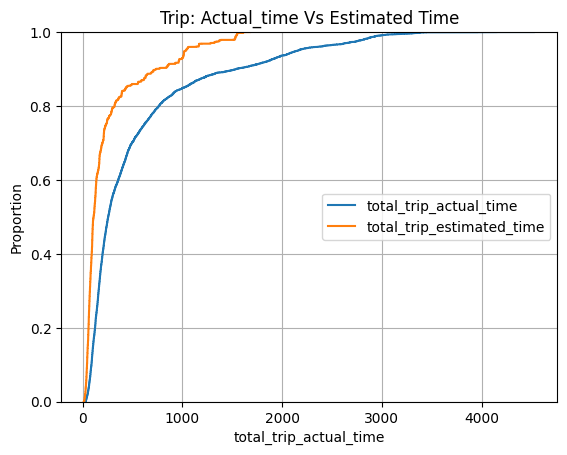

In [633]:
plt.grid()
sns.ecdfplot(Group_A,label = 'total_trip_actual_time')
sns.ecdfplot(Group_B,label ='total_trip_estimated_time')
plt.legend(loc='center right')
plt.title('Trip: Actual_time Vs Estimated Time')
plt.show()

Findings:
> 1. P_value = 0 , means the probability of seeing such a large difference between total_trip_actual_time and total_trip_estimated by **random chance**—if they were actually from the same distribution—is **effectively zero**.

> 2. The actual times have much higher variance (unpredictability) compared to the tightly clustered estimates.

> 3. The estimated distribution is consistently to the left of the actual distribution, so OSRM is systematically underestimating trip times

####**Comparing actual distance and estimated distance at trip level**

In [634]:
Ho = 'Both samples have same distribution'
Ha = 'Both samples have different distribution'
Group_A = FTL_trip_level['total_trip_actual_distance']
Group_B = FTL_trip_level['total_trip_estimated_distance']
statistic, p_value = ks_2samp(Group_A, Group_B)

alpha = 0.05

if p_value < alpha:
  print("Reject Ho, both samples have different distribution")
else:
  print("Fail to reject Ho, no sufficent evidence to claim that both samples have different distribution")

Reject Ho, both samples have different distribution


In [635]:
p_value

np.float64(1.55534511507359e-43)

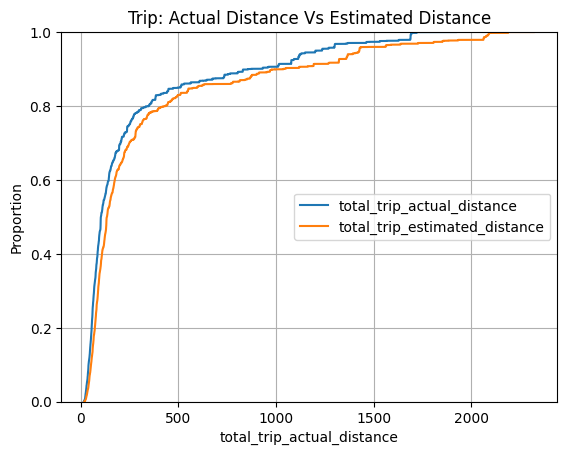

In [636]:
plt.grid()
sns.ecdfplot(Group_A,label = 'total_trip_actual_distance')
sns.ecdfplot(Group_B,label ='total_trip_estimated_distance')
plt.legend(loc='center right')
plt.title("Trip: Actual Distance Vs Estimated Distance")
plt.show()

Findings:
> 1. P_value is very low , means the probability of seeing such a large difference between total_trip_actual_distance and total_trip_estimated_distance by **random chance**—if they were actually from the same distribution—is **effectively zero**.

> 2. The estimated distance distribution is consistently to the right of the actual distribution, so OSRM is systematically overestimating trip distances.

####**Comparing trip actual time and segment actual time**

In [637]:
Ho = 'Both samples have same distribution'
Ha = 'Both samples have different distribution'
Group_A = FTL_trip_level['total_trip_actual_time']
Group_B = FTL_trip_level['segment_actual_time']
statistic, p_value = ks_2samp(Group_A, Group_B)

alpha = 0.05

if p_value < alpha:
  print("Reject Ho, both samples have different distribution")
else:
  print("Fail to reject Ho, no sufficent evidence to claim that both samples have different distribution")

Reject Ho, both samples have different distribution


In [638]:
p_value

np.float64(1.0968999545430004e-116)

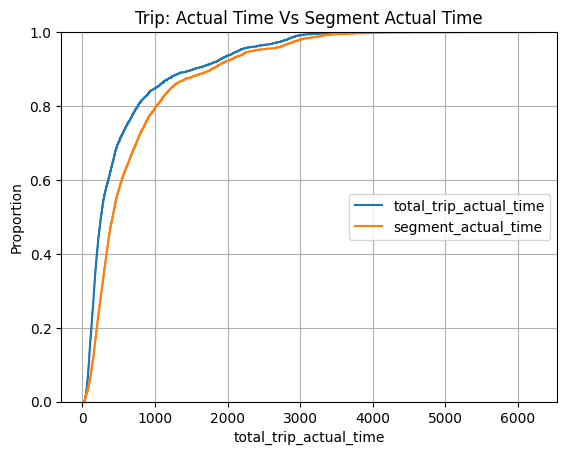

In [639]:
plt.grid()
sns.ecdfplot(Group_A,label = 'total_trip_actual_time')
sns.ecdfplot(Group_B,label ='segment_actual_time')
plt.legend(loc='center right')
plt.title("Trip: Actual Time Vs Segment Actual Time")
plt.show()

Findings:
> 1. P_value is lessa than alpha, means the probability of seeing such a large difference between total_trip_actual_time and segment_actual_time by **random chance**—if they were actually from the same distribution—is **effectively zero**.

> 2. The segment times have much higher variance (unpredictability) compared to the tightly clustered actual trip times.

> 3. The trip actual time distribution is consistently to the left of the segment actual time distribution. This can be due to certain "stationary" or "buffer" periods that are included in individual segment records.

####**Comparing trip estimated difference and segment estimated distance**

In [640]:
Ho = 'Both samples have same distribution'
Ha = 'Both samples have different distribution'
Group_A = FTL_trip_level['total_trip_estimated_distance']
Group_B = FTL_trip_level['segment_estimated_distance']
statistic, p_value = ks_2samp(Group_A, Group_B)

alpha = 0.05

if p_value < alpha:
  print("Reject Ho, both samples have different distribution")
else:
  print("Fail to reject Ho, no sufficent evidence to claim that both samples have different distribution")

Reject Ho, both samples have different distribution


In [641]:
p_value

np.float64(4.479657819164091e-193)

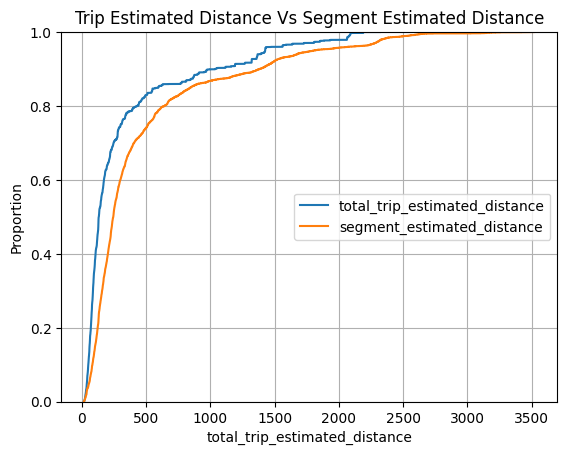

In [642]:
plt.grid()
sns.ecdfplot(Group_A,label = 'total_trip_estimated_distance')
sns.ecdfplot(Group_B,label ='segment_estimated_distance')
plt.legend(loc='center right')
plt.title("Trip Estimated Distance Vs Segment Estimated Distance")
plt.show()

Findings:
> 1. P_value is lessa than alpha, means the probability of seeing such a large difference between trip estimated distance and segment estimated distance by **random chance**—if they were actually from the same distribution—is **effectively zero**.

> 2. The segment estimated distances have much higher variance (unpredictability) compared to the tightly trip estimation distances.


####**Comparing trip estimated time and segment estimated time**

In [643]:
Ho = 'Both samples have same distribution'
Ha = 'Both samples have different distribution'
Group_A = FTL_trip_level['total_trip_estimated_time']
Group_B = FTL_trip_level['segment_estimated_time']
statistic, p_value = ks_2samp(Group_A, Group_B)

alpha = 0.05

if p_value < alpha:
  print("Reject Ho, both samples have different distribution")
else:
  print("Fail to reject Ho, no sufficent evidence to claim that both samples have different distribution")

Reject Ho, both samples have different distribution


In [644]:
p_value

np.float64(1.0797844337183153e-228)

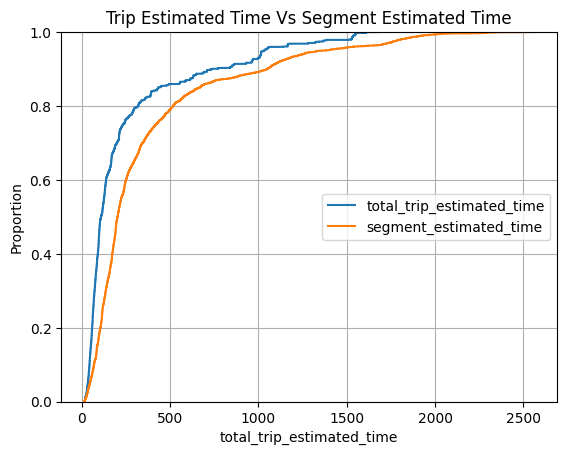

In [645]:
plt.grid()
sns.ecdfplot(Group_A,label = 'total_trip_estimated_time')
sns.ecdfplot(Group_B,label ='segment_estimated_time')
plt.legend(loc='center right')
plt.title("Trip Estimated Time Vs Segment Estimated Time")
plt.show()

Findings:
> 1. P_value is lessa than alpha, means the probability of seeing such a large difference between total_trip_estimated_time and segment_estimated_time by **random chance**—if they were actually from the same distribution—is **effectively zero**.

> 2. The segment estimated times have much higher variance (unpredictability) compared to the tightly clustered trip estimated times.

> 3. The trip actual time distribution is consistently to the left of the segment actual time distribution. This can be due to certain "stationary" or "buffer" periods that are included in individual segment records.

> **Quantifying estimation errors in time calculation**

In [646]:
from datetime import time
time_df = FTL_trip_level[['total_trip_estimated_time','total_trip_actual_time']].copy()
time_df.loc[:, 'time_error']  = FTL_trip_level['total_trip_estimated_time'] - FTL_trip_level['total_trip_actual_time']

time_df['total_trip_estimated_time'] = 	round(time_df['total_trip_estimated_time']).astype('int')
time_df['total_trip_actual_time'] = 	round(time_df['total_trip_actual_time']).astype('int')
time_df['time_error'] = 	round(time_df['time_error']).astype('int')

In [647]:
time_df.head()

,total_trip_estimated_time,total_trip_actual_time,time_error
0,394,830,-436
1,1529,2736,-1207
2,46,147,-101
3,91,291,-200
4,244,470,-226


Creating bins and checking which time bin is prone to more errors

creating time bins

In [648]:
time_df['time_bin'] = pd.qcut(time_df['total_trip_estimated_time'], q=5,
                              labels = ['<-59 mts','-59 to -90 mts','-91 to -138 mts','-138 to -319 mts','>-320 mts'])
time_df.head()

,total_trip_estimated_time,total_trip_actual_time,time_error,time_bin
0,394,830,-436,>-320 mts
1,1529,2736,-1207,>-320 mts
2,46,147,-101,<-59 mts
3,91,291,-200,-59 to -90 mts
4,244,470,-226,-138 to -319 mts


In [649]:
error_analysis = round(time_df.groupby('time_bin', observed = False).agg({
    'time_error': 'median'
}))

print(error_analysis)

                  time_error
time_bin                    
<-59 mts               -47.0
-59 to -90 mts         -81.0
-91 to -138 mts       -115.0
-138 to -319 mts      -202.0
>-320 mts             -742.0


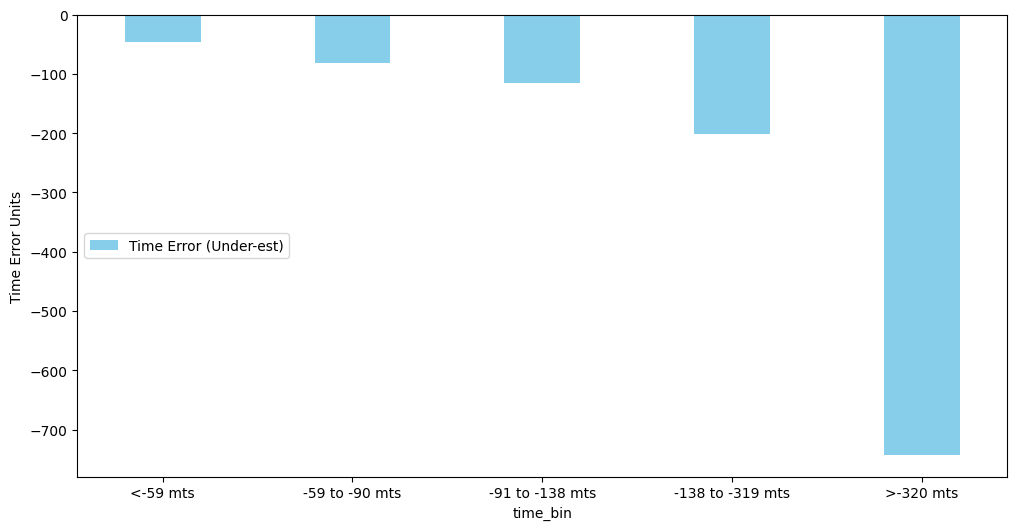

In [650]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Distance Bias (Over-estimation)
error_analysis['time_error'].plot(kind='bar', ax=ax1, color='skyblue', width=0.4, label='Time Error (Under-est)')
ax1.set_ylabel('Time Error Units')
plt.xticks(rotation=0,ha='center')
# plt.ylim(time_df['time_error'].min() - 5, time_df['time_error'].max() + 5)
ax1.legend(loc='center left')
plt.show()

OSRM errors are more when estimating time for longer trips

> **Quantifying estimation errors in distance calculation**

In [651]:
dist_df = FTL_trip_level[['total_trip_estimated_distance','total_trip_actual_distance']].copy()
dist_df.loc[:, 'distance_error']  = FTL_trip_level['total_trip_estimated_distance'] - FTL_trip_level['total_trip_actual_distance']

dist_df['total_trip_estimated_distance'] = 	round(dist_df['total_trip_estimated_distance']).astype('int')
dist_df['total_trip_actual_distance'] = 	round(dist_df['total_trip_actual_distance']).astype('int')
dist_df['distance_error'] = 	round(dist_df['distance_error']).astype('int')

In [652]:
dist_df.head()

,total_trip_estimated_distance,total_trip_actual_distance,distance_error
0,545,441,104
1,2091,1690,401
2,64,60,4
3,128,100,27
4,338,297,41


Creating bins and checking which distance bin is prone to more errors

In [653]:
dist_df['dist_bin'] = pd.qcut(dist_df['total_trip_estimated_distance'], q=5,
                              labels = ['<72 kms','72-107 kms','108-174 kms','175-433 kms','> 433 kms'])

In [654]:
dist_df

,total_trip_estimated_distance,total_trip_actual_distance,distance_error,dist_bin
0,545,441,104,> 433 kms
1,2091,1690,401,> 433 kms
2,64,60,4,<72 kms
3,128,100,27,108-174 kms
4,338,297,41,175-433 kms
...,...,...,...,...
5876,89,73,16,72-107 kms
5877,107,92,15,72-107 kms
5878,545,442,103,> 433 kms
5879,62,50,11,<72 kms


In [655]:
error_analysis = round(dist_df.groupby('dist_bin', observed = False).agg({
    'distance_error': 'mean',
}))

print(error_analysis)

             distance_error
dist_bin                   
<72 kms                10.0
72-107 kms             20.0
108-174 kms            31.0
175-433 kms            54.0
> 433 kms             197.0


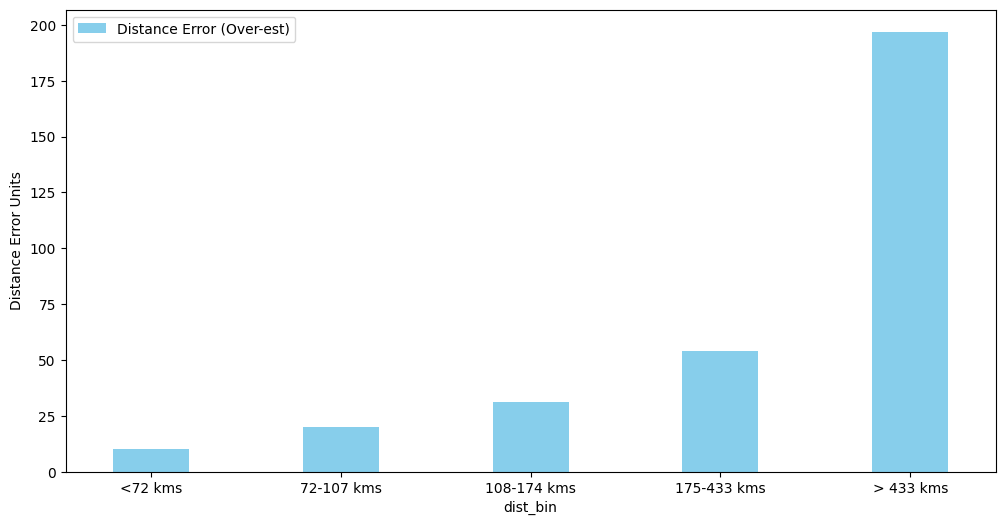

In [656]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Distance Bias (Over-estimation)
error_analysis['distance_error'].plot(kind='bar', ax=ax1, color='skyblue', width=0.4, label='Distance Error (Over-est)')
ax1.set_ylabel('Distance Error Units')
plt.xticks(rotation=0,ha='center')
ax1.legend(loc='upper left')
plt.show()

The system is more prone to error for higher trip distances.

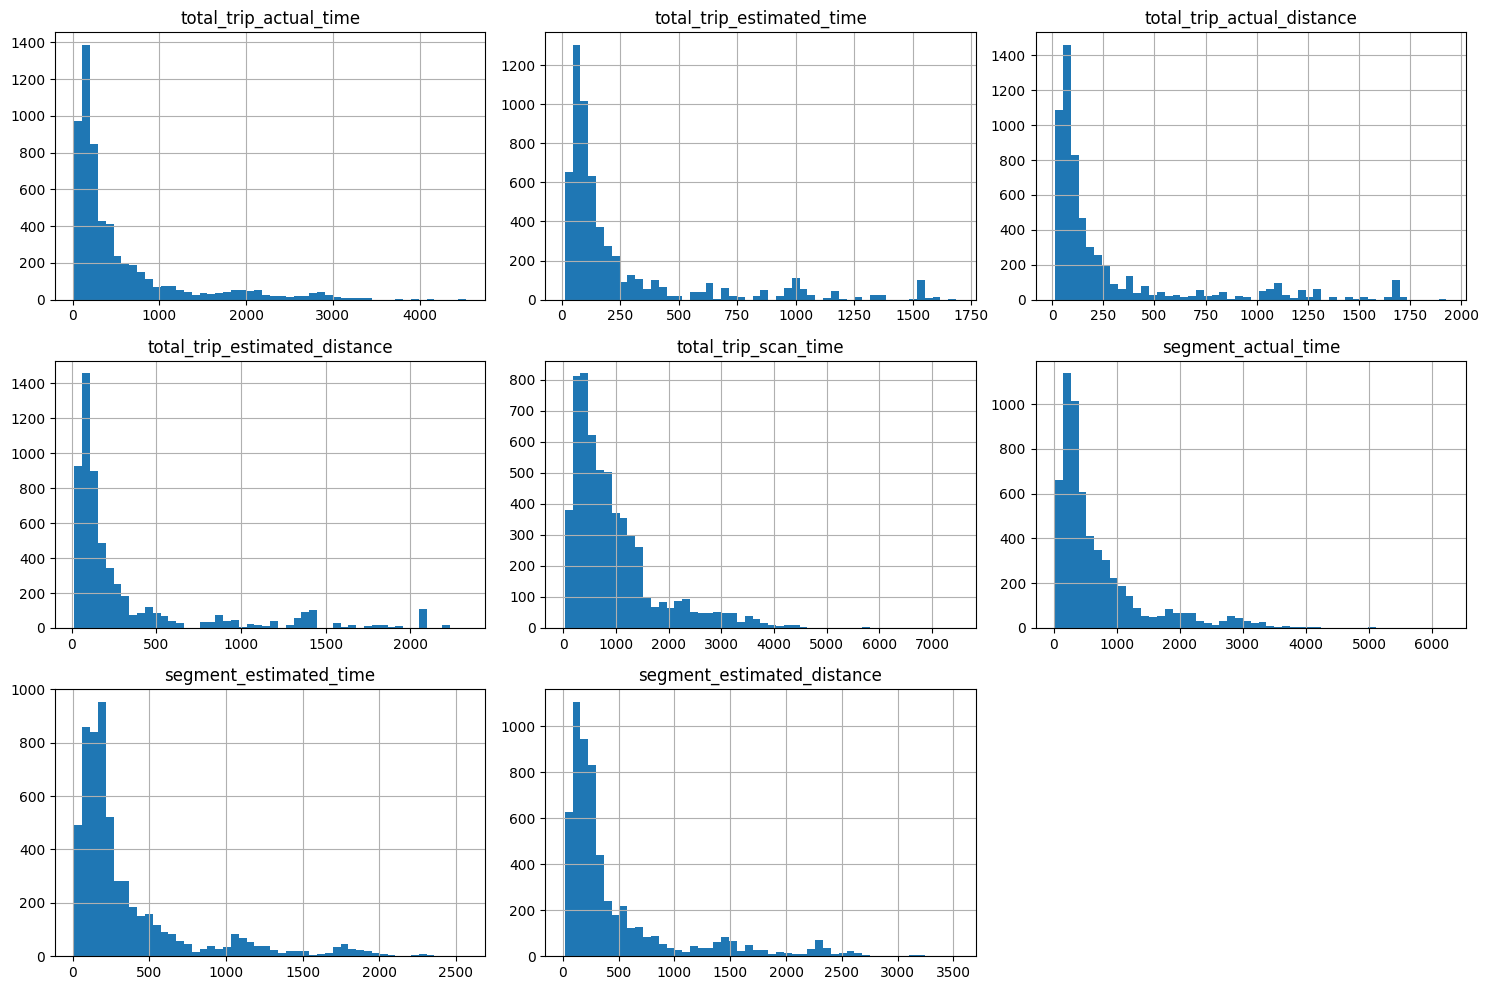

In [657]:
FTL_trip_level.hist(bins=50, figsize=(15, 10))
plt.tight_layout()
plt.show()

All features are right-skewed which indicates most of the trips are either  of short distance or short time period journey.

####**FTL_segment_level_data**

In [658]:
df_FTL.head(2)

,data,trip_creation_time,shipment_mode,trip_uuid,source_center,source_name,destination_center,destination_name,total_trip_scan_time,od_start_time,...,estimated_time,estimated_distance,segment_actual_time,segment_estimated_time,segment_estimated_distance,source_state,destination_state,date,year,month
0,training,2018-09-23 06:42:06.021680,FTL,trip-153768492602129387,IND421302AAG,Bhiwandi_Mankoli_HB (Maharashtra),IND411033AAA,Pune_Tathawde_H (Maharashtra),302,2018-09-23 06:42:06.021680,...,24,26.8622,38,24,26.8622,Maharashtra,Maharashtra,2018-09-23,2018,9
1,training,2018-09-23 06:42:06.021680,FTL,trip-153768492602129387,IND421302AAG,Bhiwandi_Mankoli_HB (Maharashtra),IND411033AAA,Pune_Tathawde_H (Maharashtra),302,2018-09-23 06:42:06.021680,...,41,54.4326,37,27,30.1058,Maharashtra,Maharashtra,2018-09-23,2018,9


In [659]:
df_FTL.drop(['trip_creation_time','source_name', 'destination_name'],axis=1, inplace=True)
df_FTL.head(2)

,data,shipment_mode,trip_uuid,source_center,destination_center,total_trip_scan_time,od_start_time,total_trip_actual_distance,start_scan_to_end_scan,total_trip_actual_time,...,estimated_time,estimated_distance,segment_actual_time,segment_estimated_time,segment_estimated_distance,source_state,destination_state,date,year,month
0,training,FTL,trip-153768492602129387,IND421302AAG,IND411033AAA,302,2018-09-23 06:42:06.021680,100.708423,302,183,...,24,26.8622,38,24,26.8622,Maharashtra,Maharashtra,2018-09-23,2018,9
1,training,FTL,trip-153768492602129387,IND421302AAG,IND411033AAA,302,2018-09-23 06:42:06.021680,100.708423,302,183,...,41,54.4326,37,27,30.1058,Maharashtra,Maharashtra,2018-09-23,2018,9


In [660]:
col_to_move = df_FTL.pop('date')
df_FTL.insert(1,'date',col_to_move)

col_to_move = df_FTL.pop('year')
df_FTL.insert(2,'year',col_to_move)

col_to_move = df_FTL.pop('month')
df_FTL.insert(3,'month',col_to_move)

In [661]:
FTL_segment_level = df_FTL.copy()

FTL_segment_level.head(2)

,data,date,year,month,shipment_mode,trip_uuid,source_center,destination_center,total_trip_scan_time,od_start_time,...,total_trip_estimated_time,actual_time,total_trip_estimated_distance,estimated_time,estimated_distance,segment_actual_time,segment_estimated_time,segment_estimated_distance,source_state,destination_state
0,training,2018-09-23,2018,9,FTL,trip-153768492602129387,IND421302AAG,IND411033AAA,302,2018-09-23 06:42:06.021680,...,95,38,129.3519,24,26.8622,38,24,26.8622,Maharashtra,Maharashtra
1,training,2018-09-23,2018,9,FTL,trip-153768492602129387,IND421302AAG,IND411033AAA,302,2018-09-23 06:42:06.021680,...,95,76,129.3519,41,54.4326,37,27,30.1058,Maharashtra,Maharashtra


In [662]:
time_df = FTL_segment_level[['segment_actual_time','segment_estimated_time']].copy()
time_df.loc[:, 'time_error']  = FTL_segment_level['segment_actual_time'] - FTL_segment_level['segment_estimated_time']
time_df
# time_df['total_trip_estimated_distance'] = 	round(time_df['total_trip_estimated_time']).astype('int')
# time_df['total_trip_actual_distance'] = 	round(time_df['total_trip_actual_time']).astype('int')
# time_df['distance_error'] = 	round(time_df['time_error']).astype('int')

,segment_actual_time,segment_estimated_time,time_error
0,38,24,14
1,37,27,10
2,41,26,15
3,23,14,9
4,41,15,26
...,...,...,...
99127,56,25,31
99128,46,26,20
99129,42,32,10
99130,53,14,39


####**Checking outliers**

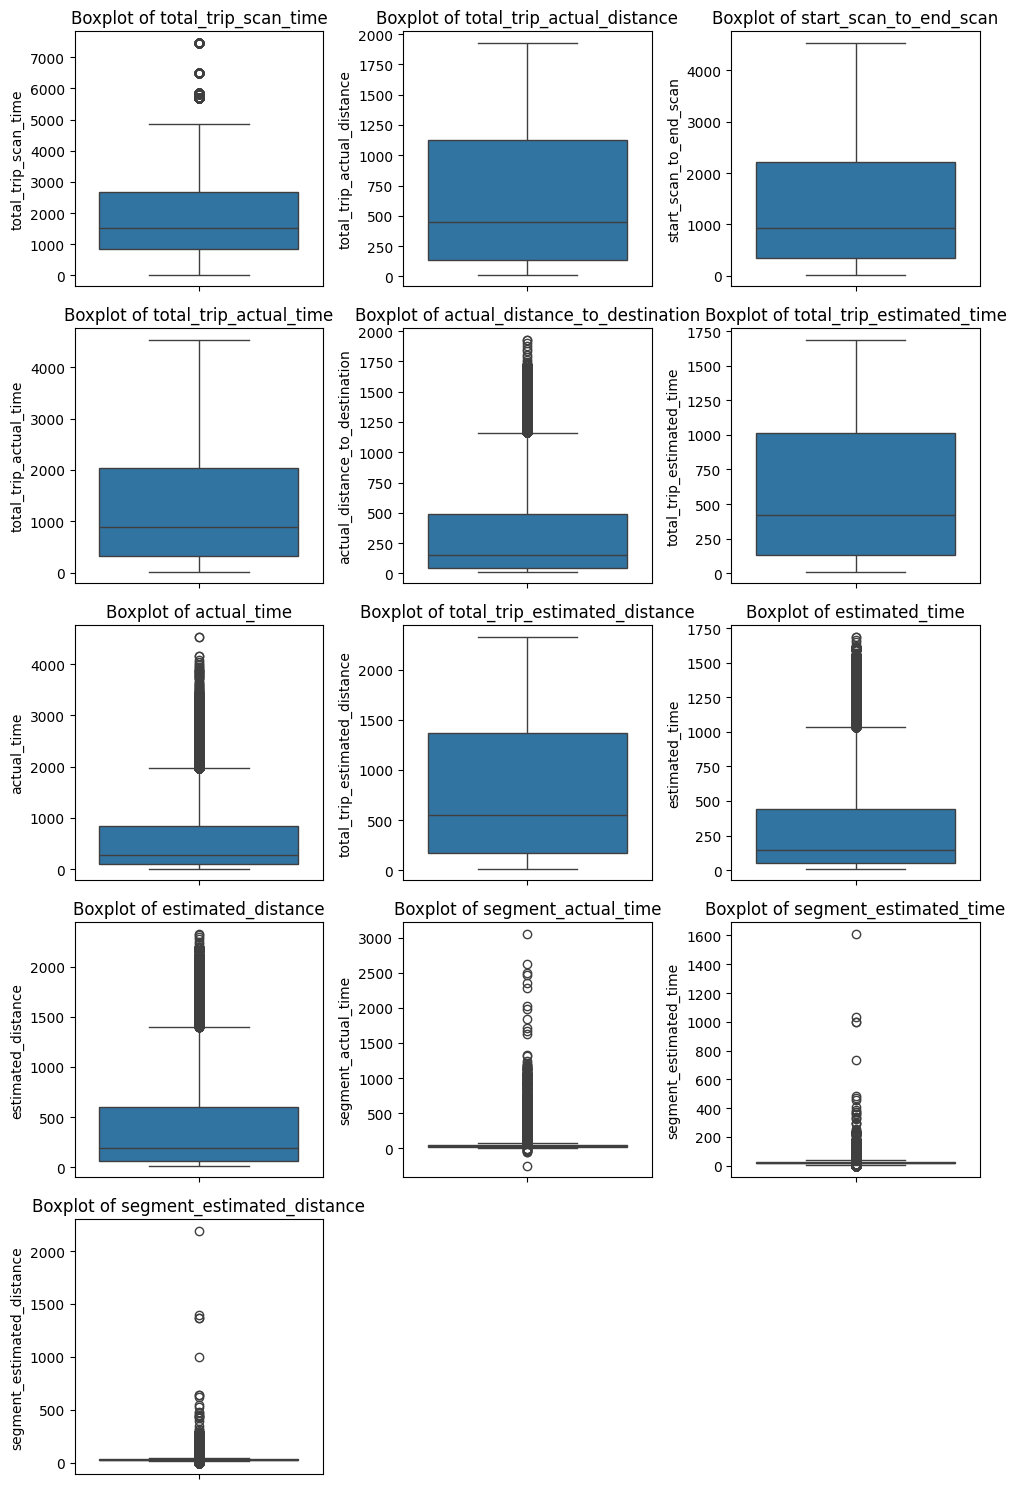

In [663]:
numeric_cols = FTL_segment_level.select_dtypes(include=['number'])
num_cols = numeric_cols.iloc[:,2:].columns

plt.figure(figsize=(10, 15))

# 3. Loop through columns and create subplots
for i, col in enumerate(num_cols):
    plt.subplot(len(num_cols) // 3 + 1, 3, i + 1) # Create a grid (3 columns wide)
    sns.boxplot(y=numeric_cols[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout() # Ensures titles and labels don't overlap
plt.show()

removing it

In [664]:
# Calculate Q1, Q3, and IQR for all columns at once
Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)
IQR = Q3 - Q1

#  Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mask = ((numeric_cols >= lower_bound) & (numeric_cols <= upper_bound)).all(axis=1)

# Apply the mask to your original dataframe
df_FTL_cleaned = df_FTL[mask]

In [665]:
df_FTL_cleaned.shape

(65239, 24)

####**Normalizing numerical data**

In [666]:
numerical_cols = df_FTL_cleaned.select_dtypes(include=['number'])
for cols in numerical_cols:
  print(cols)
  print(df_FTL[cols].max())
  print(df_FTL[cols].min())
  print("="*20)

year
2018
2018
month
10
9
total_trip_scan_time
7458
30
total_trip_actual_distance
1927.4477046975032
15.038337991247095
start_scan_to_end_scan
4535
23
total_trip_actual_time
4532
20
actual_distance_to_destination
1927.4477046975032
15.000648498677483
total_trip_estimated_time
1686
12
actual_time
4532
12
total_trip_estimated_distance
2326.1991000000003
17.1115
estimated_time
1686
11
estimated_distance
2326.1991000000003
15.7792
segment_actual_time
3051
-244
segment_estimated_time
1611
0
segment_estimated_distance
2191.4037000000003
0.0


The range of many columns are high, which means we have to carry out normalization to ensure that features with larger numerical ranges don't dominate the analysis just because of their size

In [667]:
num_cols

Index(['total_trip_scan_time', 'total_trip_actual_distance',
       'start_scan_to_end_scan', 'total_trip_actual_time',
       'actual_distance_to_destination', 'total_trip_estimated_time',
       'actual_time', 'total_trip_estimated_distance', 'estimated_time',
       'estimated_distance', 'segment_actual_time', 'segment_estimated_time',
       'segment_estimated_distance'],
      dtype='object')

In [668]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_FTL_cleaned[num_cols]= scaler.fit_transform(df_FTL_cleaned[num_cols])
df_FTL_cleaned

/tmp/ipython-input-353181975.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_FTL_cleaned[num_cols]= scaler.fit_transform(df_FTL_cleaned[num_cols])


,data,date,year,month,shipment_mode,trip_uuid,source_center,destination_center,total_trip_scan_time,od_start_time,...,total_trip_estimated_time,actual_time,total_trip_estimated_distance,estimated_time,estimated_distance,segment_actual_time,segment_estimated_time,segment_estimated_distance,source_state,destination_state
0,training,2018-09-23,2018,9,FTL,trip-153768492602129387,IND421302AAG,IND411033AAA,0.056478,2018-09-23 06:42:06.021680,...,0.049014,0.013306,0.048608,0.012733,0.007998,0.520548,0.533333,0.505093,Maharashtra,Maharashtra
1,training,2018-09-23,2018,9,FTL,trip-153768492602129387,IND421302AAG,IND411033AAA,0.056478,2018-09-23 06:42:06.021680,...,0.049014,0.032753,0.048608,0.029383,0.027894,0.506849,0.633333,0.617862,Maharashtra,Maharashtra
2,training,2018-09-23,2018,9,FTL,trip-153768492602129387,IND421302AAG,IND411033AAA,0.056478,2018-09-23 06:42:06.021680,...,0.049014,0.053736,0.048608,0.055828,0.053322,0.561644,0.600000,0.796198,Maharashtra,Maharashtra
3,training,2018-09-23,2018,9,FTL,trip-153768492602129387,IND421302AAG,IND411033AAA,0.056478,2018-09-23 06:42:06.021680,...,0.049014,0.066018,0.048608,0.067581,0.066835,0.315068,0.200000,0.170826,Maharashtra,Maharashtra
4,training,2018-09-23,2018,9,FTL,trip-153768492602129387,IND421302AAG,IND411033AAA,0.056478,2018-09-23 06:42:06.021680,...,0.049014,0.087513,0.048608,0.082272,0.081959,0.561644,0.233333,0.299824,Maharashtra,Maharashtra
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99124,training,2018-09-26,2018,9,FTL,trip-153799142965708367,IND457226AAA,IND382430AAB,0.174211,2018-09-27 06:55:50.265761,...,0.165571,0.207779,0.160616,0.230167,0.218012,0.630137,0.966667,0.959845,Madhya Pradesh,Gujarat
99127,training,2018-09-22,2018,9,FTL,trip-153761584139918815,IND421302AAG,IND411033AAA,0.121262,2018-09-22 11:30:41.399439,...,0.049014,0.022518,0.048524,0.013712,0.008710,0.767123,0.566667,0.539394,Maharashtra,Maharashtra
99128,training,2018-09-22,2018,9,FTL,trip-153761584139918815,IND421302AAG,IND411033AAA,0.121262,2018-09-22 11:30:41.399439,...,0.049014,0.046059,0.048524,0.030362,0.028205,0.630137,0.600000,0.598525,Maharashtra,Maharashtra
99129,training,2018-09-22,2018,9,FTL,trip-153761584139918815,IND421302AAG,IND411033AAA,0.121262,2018-09-22 11:30:41.399439,...,0.049014,0.067554,0.048524,0.055828,0.053526,0.575342,0.800000,0.760691,Maharashtra,Maharashtra


In [669]:
cat_cols = df_FTL_cleaned.select_dtypes(include=['string']).iloc[:,1:5] # removing data column
cat_cols

,shipment_mode,trip_uuid,source_center,destination_center
0,FTL,trip-153768492602129387,IND421302AAG,IND411033AAA
1,FTL,trip-153768492602129387,IND421302AAG,IND411033AAA
2,FTL,trip-153768492602129387,IND421302AAG,IND411033AAA
3,FTL,trip-153768492602129387,IND421302AAG,IND411033AAA
4,FTL,trip-153768492602129387,IND421302AAG,IND411033AAA
...,...,...,...,...
99124,FTL,trip-153799142965708367,IND457226AAA,IND382430AAB
99127,FTL,trip-153761584139918815,IND421302AAG,IND411033AAA
99128,FTL,trip-153761584139918815,IND421302AAG,IND411033AAA
99129,FTL,trip-153761584139918815,IND421302AAG,IND411033AAA


In [670]:
cat_cols.nunique()

,0
shipment_mode,1
trip_uuid,5130
source_center,894
destination_center,892


Encoding cat_cols to numbers

In [671]:
df_FTL_cleaned.drop(['source_center', 'destination_center'],axis=1, inplace=True)

/tmp/ipython-input-2949173417.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_FTL_cleaned.drop(['source_center', 'destination_center'],axis=1, inplace=True)


In [672]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_FTL_cleaned.loc[:,"shipment_mode"] = le.fit_transform(df_FTL_cleaned["shipment_mode"])
df_FTL_cleaned.loc[:,"trip_uuid"] = le.fit_transform(df_FTL_cleaned["trip_uuid"])
df_FTL_cleaned.loc[:,"source_state"] = le.fit_transform(df_FTL_cleaned["source_state"])
df_FTL_cleaned.loc[:,"destination_state"] = le.fit_transform(df_FTL_cleaned["destination_state"])

/tmp/ipython-input-3069206377.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 0 0 0]' has dtype incompatible with string, please explicitly cast to a compatible dtype first.
  df_FTL_cleaned.loc[:,"shipment_mode"] = le.fit_transform(df_FTL_cleaned["shipment_mode"])
/tmp/ipython-input-3069206377.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[3249 3249 3249 ... 3006 3006 3006]' has dtype incompatible with string, please explicitly cast to a compatible dtype first.
  df_FTL_cleaned.loc[:,"trip_uuid"] = le.fit_transform(df_FTL_cleaned["trip_uuid"])


In [674]:
col_to_move = df_FTL_cleaned.pop('source_state')
df_FTL_cleaned.insert(6,'source_state', col_to_move)

col_to_move = df_FTL_cleaned.pop('destination_state')
df_FTL_cleaned.insert(7,'destination_state', col_to_move)

In [675]:
df_FTL_cleaned.head()

,data,date,year,month,shipment_mode,trip_uuid,source_state,destination_state,total_trip_scan_time,od_start_time,...,total_trip_actual_time,actual_distance_to_destination,total_trip_estimated_time,actual_time,total_trip_estimated_distance,estimated_time,estimated_distance,segment_actual_time,segment_estimated_time,segment_estimated_distance
0,training,2018-09-23,2018,9,0,3249,16,16,0.056478,2018-09-23 06:42:06.021680,...,0.036126,0.007164,0.049014,0.013306,0.048608,0.012733,0.007998,0.520548,0.533333,0.505093
1,training,2018-09-23,2018,9,0,3249,16,16,0.056478,2018-09-23 06:42:06.021680,...,0.036126,0.025445,0.049014,0.032753,0.048608,0.029383,0.027894,0.506849,0.633333,0.617862
2,training,2018-09-23,2018,9,0,3249,16,16,0.056478,2018-09-23 06:42:06.021680,...,0.036126,0.050697,0.049014,0.053736,0.048608,0.055828,0.053322,0.561644,0.600000,0.796198
3,training,2018-09-23,2018,9,0,3249,16,16,0.056478,2018-09-23 06:42:06.021680,...,0.036126,0.064047,0.049014,0.066018,0.048608,0.067581,0.066835,0.315068,0.200000,0.170826
4,training,2018-09-23,2018,9,0,3249,16,16,0.056478,2018-09-23 06:42:06.021680,...,0.036126,0.075121,0.049014,0.087513,0.048608,0.082272,0.081959,0.561644,0.233333,0.299824


###**Analysis on Carting shipments**

In [676]:
df_cart.head(2)

,data,trip_creation_time,shipment_mode,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,estimated_time,estimated_distance,segment_actual_time,segment_estimated_time,segment_estimated_distance,source_state,destination_state
0,training,2018-09-20 02:35:36.476840,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86,10.43566,14,11,11.9653,14,11,11.9653,Gujarat,Gujarat
1,training,2018-09-20 02:35:36.476840,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86,18.936842,24,20,21.7243,10,9,9.759,Gujarat,Gujarat


In [677]:
# dropping od_end_time since start_scan_to_end_scan captures the difference between od_start_time and od_end_time

df_cart = df_cart.drop(columns=['od_end_time'], axis=1)

> checking if trip_creation_time and od_start_time holds same value

In [678]:
check_match_grp = df_cart.groupby(['trip_uuid','trip_creation_time'])['od_start_time'].min().reset_index()
check_match_grp

,trip_uuid,trip_creation_time,od_start_time
0,trip-153671042288605164,2018-09-12 00:00:22.886430,2018-09-12 00:00:22.886430
1,trip-153671046011330457,2018-09-12 00:01:00.113710,2018-09-12 00:01:00.113710
2,trip-153671055416136166,2018-09-12 00:02:34.161600,2018-09-12 00:02:34.161600
3,trip-153671066201138152,2018-09-12 00:04:22.011653,2018-09-12 00:04:22.011653
4,trip-153671066826362165,2018-09-12 00:04:28.263977,2018-09-12 00:04:28.263977
...,...,...,...
8901,trip-153861091843037040,2018-10-03 23:55:18.430664,2018-10-03 23:55:18.430664
8902,trip-153861095625827784,2018-10-03 23:55:56.258533,2018-10-03 23:55:56.258533
8903,trip-153861104386292051,2018-10-03 23:57:23.863155,2018-10-03 23:57:23.863155
8904,trip-153861106442901555,2018-10-03 23:57:44.429324,2018-10-03 23:57:44.429324


In [681]:
match_count_cart = (check_match_grp['trip_creation_time'].unique() == check_match_grp['od_start_time'].unique()).sum()
print(match_count_cart,",", check_match_grp.shape[0])

7840 , 8906


> **out of 8906 carting shipments 7840 shipments have the same trip_creation_time and od_start_time, which means zero latency indicating operational efficiency**

**Checking for processing delays**

> if there is a huge gap between trip_creation_time and od_start_time, then it is considerd as processing delays

In [682]:
# 1. Group and find the earliest start for EVERY trip
check_delay_grp = df_cart.groupby(['trip_uuid','trip_creation_time'])['od_start_time'].min().reset_index()

# 2. Calculate the delay for EVERY trip
check_delay_grp['delay'] = check_delay_grp['od_start_time'] - check_delay_grp['trip_creation_time']

# 3. FILTER: Overwrite the group to keep ONLY non-zero delays
check_delay_grp = check_delay_grp[check_delay_grp['delay'] != pd.Timedelta(0)]

# 4. Now sort - the zeroes will be gone
check_delay_grp['delay'].sort_values(ascending=False)


,delay
1495,1 days 23:06:13.823816
5778,1 days 08:43:25.606694
5789,1 days 05:16:45.257843
5776,1 days 05:15:12.414234
7497,1 days 03:09:44.348996
...,...
7216,0 days 00:17:12.775280
1696,0 days 00:12:14.284975
6747,0 days 00:11:51.274033
3445,0 days 00:09:18.115597


There are many deliveries which started one day after trip_creation_time which can be attributed to operational delays

> Checking for duplicate values

In [683]:
df_cart.duplicated(keep=False).sum()

np.int64(0)

>There are nil duplicates in df_cart

Since start_scan_to_end_scan is segment-level data first we need to pick max/first value from each segment and then do aggregation

In [684]:
segment_level = df_cart.groupby(['trip_uuid', 'source_center', 'destination_center']).agg({
    'start_scan_to_end_scan': 'max'
}).reset_index()

# Step 2: Sum those segment values to get the total trip-level time
trip_level_sum = segment_level.groupby('trip_uuid')['start_scan_to_end_scan'].sum().reset_index()

In [685]:
trip_level_sum.head()

,trip_uuid,start_scan_to_end_scan
0,trip-153671042288605164,180
1,trip-153671046011330457,100
2,trip-153671055416136166,189
3,trip-153671066201138152,98
4,trip-153671066826362165,146


In [686]:
trip_lookup = trip_level_sum.set_index('trip_uuid')['start_scan_to_end_scan']

# 2. Map it back to the original df
df_cart['total_trip_scan_time'] = df_cart['trip_uuid'].map(trip_lookup)


In [687]:
df_cart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45184 entries, 0 to 45183
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   data                            45184 non-null  string        
 1   trip_creation_time              45184 non-null  datetime64[ns]
 2   shipment_mode                   45184 non-null  string        
 3   trip_uuid                       45184 non-null  string        
 4   source_center                   45184 non-null  string        
 5   source_name                     45184 non-null  string        
 6   destination_center              45184 non-null  string        
 7   destination_name                45184 non-null  string        
 8   od_start_time                   45184 non-null  datetime64[ns]
 9   start_scan_to_end_scan          45184 non-null  Int64         
 10  actual_distance_to_destination  45184 non-null  Float64       
 11  ac

In [688]:
# re-arranging the columns
col_to_move = df_cart.pop('total_trip_scan_time')

df_cart.insert(8, 'total_trip_scan_time', col_to_move)

Trip level metrics need to be aggregated to get a single value for each trip_uuid and grouped to check the aggregated values of segment-level metrics

In [689]:
df_cart['total_trip_actual_time'] = df_cart.groupby('trip_uuid')['actual_time'].transform('max')
df_cart['total_trip_actual_distance'] = df_cart.groupby('trip_uuid')['actual_distance_to_destination'].transform('max')
df_cart['total_trip_estimated_time'] = df_cart.groupby('trip_uuid')['estimated_time'].transform('max')
df_cart['total_trip_estimated_distance'] = df_cart.groupby('trip_uuid')['estimated_distance'].transform('max')

Re-arranging columns

In [690]:
col_to_move = df_cart.pop('total_trip_actual_distance')

df_cart.insert(10, 'total_trip_actual_distance', col_to_move)

In [691]:
col_to_move = df_cart.pop('total_trip_actual_time')

df_cart.insert(12, 'total_trip_actual_time', col_to_move)

In [692]:
col_to_move = df_cart.pop('total_trip_estimated_time')

df_cart.insert(14, 'total_trip_estimated_time', col_to_move)

In [693]:
col_to_move = df_cart.pop('total_trip_estimated_distance')

df_cart.insert(16, 'total_trip_estimated_distance', col_to_move)

In [694]:
df_cart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45184 entries, 0 to 45183
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   data                            45184 non-null  string        
 1   trip_creation_time              45184 non-null  datetime64[ns]
 2   shipment_mode                   45184 non-null  string        
 3   trip_uuid                       45184 non-null  string        
 4   source_center                   45184 non-null  string        
 5   source_name                     45184 non-null  string        
 6   destination_center              45184 non-null  string        
 7   destination_name                45184 non-null  string        
 8   total_trip_scan_time            45184 non-null  Int64         
 9   od_start_time                   45184 non-null  datetime64[ns]
 10  total_trip_actual_distance      45184 non-null  Float64       
 11  st

In [696]:
df_cart[df_cart['trip_uuid']=='trip-153671042288605164']

,data,trip_creation_time,shipment_mode,trip_uuid,source_center,source_name,destination_center,destination_name,total_trip_scan_time,od_start_time,...,total_trip_estimated_time,actual_time,total_trip_estimated_distance,estimated_time,estimated_distance,segment_actual_time,segment_estimated_time,segment_estimated_distance,source_state,destination_state
20749,training,2018-09-12 00:00:22.886430,Carting,trip-153671042288605164,IND572101AAA,Tumkur_Veersagr_I (Karnataka),IND561203AAB,Doddablpur_ChikaDPP_D (Karnataka),180,2018-09-12 00:00:22.886430,...,42,14,56.9116,8,10.3544,14,8,10.3544,Karnataka,Karnataka
20750,training,2018-09-12 00:00:22.886430,Carting,trip-153671042288605164,IND572101AAA,Tumkur_Veersagr_I (Karnataka),IND561203AAB,Doddablpur_ChikaDPP_D (Karnataka),180,2018-09-12 00:00:22.886430,...,42,24,56.9116,15,20.1431,10,6,9.7887,Karnataka,Karnataka
20751,training,2018-09-12 00:00:22.886430,Carting,trip-153671042288605164,IND572101AAA,Tumkur_Veersagr_I (Karnataka),IND561203AAB,Doddablpur_ChikaDPP_D (Karnataka),180,2018-09-12 00:00:22.886430,...,42,40,56.9116,21,28.6245,16,5,8.4814,Karnataka,Karnataka
20752,training,2018-09-12 00:00:22.886430,Carting,trip-153671042288605164,IND572101AAA,Tumkur_Veersagr_I (Karnataka),IND561203AAB,Doddablpur_ChikaDPP_D (Karnataka),180,2018-09-12 00:00:22.886430,...,42,53,56.9116,30,40.899,13,9,12.2746,Karnataka,Karnataka
20753,training,2018-09-12 00:00:22.886430,Carting,trip-153671042288605164,IND572101AAA,Tumkur_Veersagr_I (Karnataka),IND561203AAB,Doddablpur_ChikaDPP_D (Karnataka),180,2018-09-12 00:00:22.886430,...,42,76,56.9116,39,52.1825,22,8,11.2834,Karnataka,Karnataka
20754,training,2018-09-12 00:00:22.886430,Carting,trip-153671042288605164,IND572101AAA,Tumkur_Veersagr_I (Karnataka),IND561203AAB,Doddablpur_ChikaDPP_D (Karnataka),180,2018-09-12 00:00:22.886430,...,42,96,56.9116,42,56.9116,20,3,3.8074,Karnataka,Karnataka
20755,training,2018-09-12 00:00:22.886430,Carting,trip-153671042288605164,IND561203AAB,Doddablpur_ChikaDPP_D (Karnataka),IND562101AAA,Chikblapur_ShntiSgr_D (Karnataka),180,2018-09-12 02:03:09.655591,...,42,18,56.9116,10,10.8633,18,10,10.8633,Karnataka,Karnataka
20756,training,2018-09-12 00:00:22.886430,Carting,trip-153671042288605164,IND561203AAB,Doddablpur_ChikaDPP_D (Karnataka),IND562101AAA,Chikblapur_ShntiSgr_D (Karnataka),180,2018-09-12 02:03:09.655591,...,42,31,56.9116,19,21.253,13,9,10.3898,Karnataka,Karnataka
20757,training,2018-09-12 00:00:22.886430,Carting,trip-153671042288605164,IND561203AAB,Doddablpur_ChikaDPP_D (Karnataka),IND562101AAA,Chikblapur_ShntiSgr_D (Karnataka),180,2018-09-12 02:03:09.655591,...,42,47,56.9116,26,28.1994,15,7,6.9464,Karnataka,Karnataka


**Extracting year, month, day from datetime data**

In [697]:
df_cart['date'] = df_cart['trip_creation_time'].dt.date
df_cart['year'] = df_cart['trip_creation_time'].dt.year
df_cart['month'] = df_cart['trip_creation_time'].dt.month

In [698]:
print(type(df_cart['date'].loc[1]))
print(type(df_cart['year'].loc[1]))
print(type(df_cart['month'].loc[1]))

<class 'datetime.date'>
<class 'numpy.int32'>
<class 'numpy.int32'>


Year-wise, month-wise, day-wise breakdown of carting deliveries

In [699]:
print(df_cart.groupby('date')['trip_uuid'].nunique())
print("="*20)
print(df_cart.groupby('year')['trip_uuid'].nunique())
print("="*20)
print(df_cart.groupby('month')['trip_uuid'].nunique())

date
2018-09-12    454
2018-09-13    445
2018-09-14    426
2018-09-15    484
2018-09-16    330
2018-09-17    427
2018-09-18    476
2018-09-19    395
2018-09-20    400
2018-09-21    441
2018-09-22    450
2018-09-23    351
2018-09-24    373
2018-09-25    403
2018-09-26    388
2018-09-27    427
2018-09-28    395
2018-09-29    401
2018-09-30    304
2018-10-01    392
2018-10-02    336
2018-10-03    408
Name: trip_uuid, dtype: int64
year
2018    8906
Name: trip_uuid, dtype: int64
month
9     7770
10    1136
Name: trip_uuid, dtype: int64


####**carting trip level data**

In [701]:
cart_trip_level = df_cart.groupby(['trip_uuid',
                'total_trip_actual_time',
                'total_trip_estimated_time',
                'total_trip_actual_distance',
                'total_trip_estimated_distance',
                'total_trip_scan_time']).agg(
                        {
                        'segment_actual_time':'sum',
                        'segment_estimated_time':'sum',
                        'segment_estimated_distance':'sum'}).reset_index()
cart_trip_level.head()

,trip_uuid,total_trip_actual_time,total_trip_estimated_time,total_trip_actual_distance,total_trip_estimated_distance,total_trip_scan_time,segment_actual_time,segment_estimated_time,segment_estimated_distance
0,trip-153671042288605164,96,42,48.54289,56.9116,180,141,65,84.1894
1,trip-153671046011330457,59,15,17.175274,19.68,100,59,16,19.8766
2,trip-153671055416136166,40,12,15.325529,16.2225,189,60,23,28.0647
3,trip-153671066201138152,24,13,9.10051,12.0184,98,24,13,12.0184
4,trip-153671066826362165,39,18,12.352948,15.077,146,64,34,28.9203


In [702]:
cart_trip_level.shape

(8906, 9)

**Data is grouped for 8906 unique trip_uuids**

####**Comparing trip actual time and trip estimated time**

In [703]:
from scipy.stats import ks_2samp
Ho = 'Both samples have same distribution'
Ha = 'Both samples have different distribution'
Group_A = cart_trip_level['total_trip_actual_time']
Group_B = cart_trip_level['total_trip_estimated_time']
statistic, p_value = ks_2samp(Group_A, Group_B)

alpha = 0.05

if p_value < alpha:
  print("Reject Ho, both samples have different distribution")
else:
  print("Fail to reject Ho, no sufficent evidence to claim that both samples have different distribution")

Reject Ho, both samples have different distribution


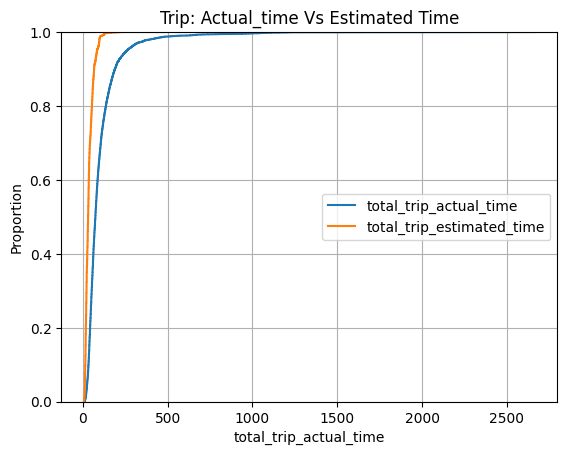

In [704]:
plt.grid()
sns.ecdfplot(Group_A,label = 'total_trip_actual_time')
sns.ecdfplot(Group_B,label ='total_trip_estimated_time')
plt.legend(loc='center right')
plt.title('Trip: Actual_time Vs Estimated Time')
plt.show()

Findings:
> 1. P_value = 0 , means the probability of seeing such a large difference between total_trip_actual_time and total_trip_estimated by **random chance**—if they were actually from the same distribution—is **effectively zero**.

> 2. The actual times have much higher variance (unpredictability) compared to the tightly clustered estimates.

> 3. The estimated distribution is consistently to the left of the actual distribution, so OSRM is systematically underestimating trip times

####**Comparing actual distance and estimated distance at trip level**

In [705]:
Ho = 'Both samples have same distribution'
Ha = 'Both samples have different distribution'
Group_A = cart_trip_level['total_trip_actual_distance']
Group_B = cart_trip_level['total_trip_estimated_distance']
statistic, p_value = ks_2samp(Group_A, Group_B)

alpha = 0.05

if p_value < alpha:
  print("Reject Ho, both samples have different distribution")
else:
  print("Fail to reject Ho, no sufficent evidence to claim that both samples have different distribution")

Reject Ho, both samples have different distribution


In [706]:
p_value

np.float64(1.3397217676189569e-151)

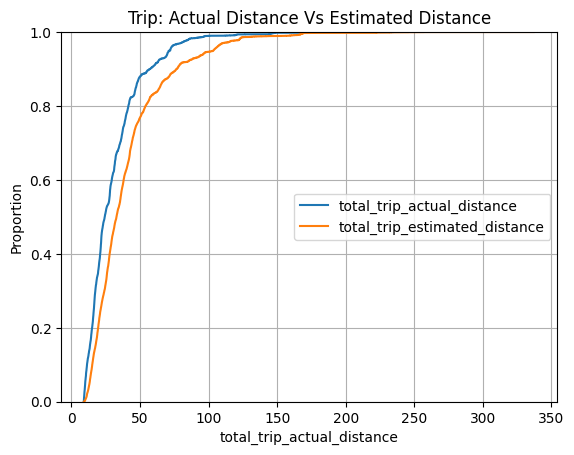

In [707]:
plt.grid()
sns.ecdfplot(Group_A,label = 'total_trip_actual_distance')
sns.ecdfplot(Group_B,label ='total_trip_estimated_distance')
plt.legend(loc='center right')
plt.title("Trip: Actual Distance Vs Estimated Distance")
plt.show()

Findings:
> 1. P_value is very low , means the probability of seeing such a large difference between total_trip_actual_distance and total_trip_estimated_distance by **random chance**—if they were actually from the same distribution—is **effectively zero**.

> 2. The estimated distance distribution is consistently to the right of the actual distribution, so OSRM is systematically overestimating trip distances.

####**Comparing trip actual time and segment actual time**

In [708]:
Ho = 'Both samples have same distribution'
Ha = 'Both samples have different distribution'
Group_A = cart_trip_level['total_trip_actual_time']
Group_B = cart_trip_level['segment_actual_time']
statistic, p_value = ks_2samp(Group_A, Group_B)

alpha = 0.05

if p_value < alpha:
  print("Reject Ho, both samples have different distribution")
else:
  print("Fail to reject Ho, no sufficent evidence to claim that both samples have different distribution")

Reject Ho, both samples have different distribution


In [709]:
p_value

np.float64(1.3276351083303402e-20)

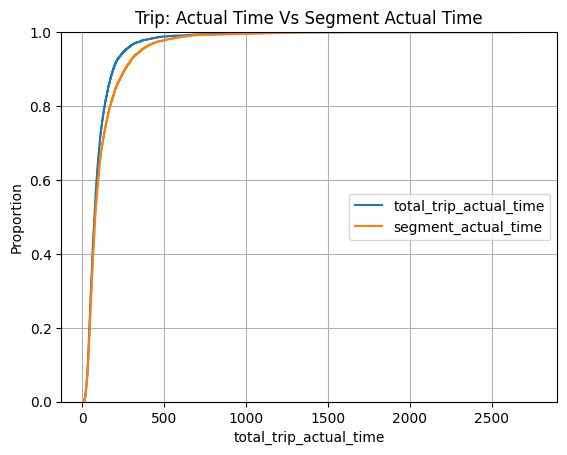

In [710]:
plt.grid()
sns.ecdfplot(Group_A,label = 'total_trip_actual_time')
sns.ecdfplot(Group_B,label ='segment_actual_time')
plt.legend(loc='center right')
plt.title("Trip: Actual Time Vs Segment Actual Time")
plt.show()

Findings:
> 1. P_value is less than alpha, means the probability of seeing such a large difference between total_trip_actual_time and segment_actual_time by **random chance**—if they were actually from the same distribution—is **effectively zero**.

> 2. The segment estimated times are closer to actual trip times at lower timeframes but deviated at higher timees.


####**Comparing trip estimated difference and segment estimated distance**

In [711]:
Ho = 'Both samples have same distribution'
Ha = 'Both samples have different distribution'
Group_A = cart_trip_level['total_trip_estimated_distance']
Group_B = cart_trip_level['segment_estimated_distance']
statistic, p_value = ks_2samp(Group_A, Group_B)

alpha = 0.05

if p_value < alpha:
  print("Reject Ho, both samples have different distribution")
else:
  print("Fail to reject Ho, no sufficent evidence to claim that both samples have different distribution")

Reject Ho, both samples have different distribution


In [712]:
p_value

np.float64(9.413248036348897e-69)

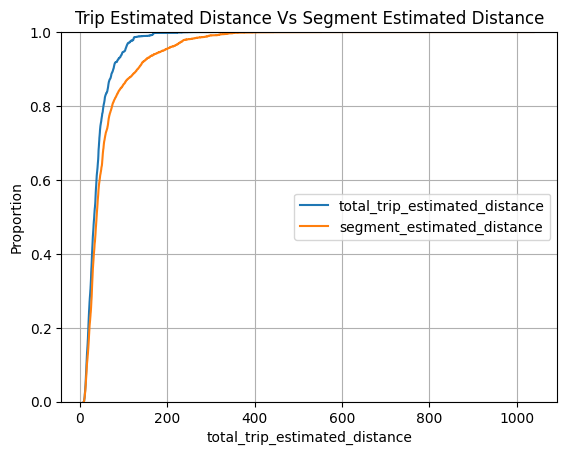

In [713]:
plt.grid()
sns.ecdfplot(Group_A,label = 'total_trip_estimated_distance')
sns.ecdfplot(Group_B,label ='segment_estimated_distance')
plt.legend(loc='center right')
plt.title("Trip Estimated Distance Vs Segment Estimated Distance")
plt.show()

Findings:
> 1. P_value is lessa than alpha, means the probability of seeing such a large difference between trip estimated distance and segment estimated distance by **random chance**—if they were actually from the same distribution—is **effectively zero**.

> 2. The segment estimated distances have much higher variance (unpredictability) compared to the tightly trip estimation distances.


####**Comparing trip estimated time and segment estimated time**

In [714]:
Ho = 'Both samples have same distribution'
Ha = 'Both samples have different distribution'
Group_A = cart_trip_level['total_trip_estimated_time']
Group_B = cart_trip_level['segment_estimated_time']
statistic, p_value = ks_2samp(Group_A, Group_B)

alpha = 0.05

if p_value < alpha:
  print("Reject Ho, both samples have different distribution")
else:
  print("Fail to reject Ho, no sufficent evidence to claim that both samples have different distribution")

Reject Ho, both samples have different distribution


In [715]:
p_value

np.float64(7.285959749963167e-62)

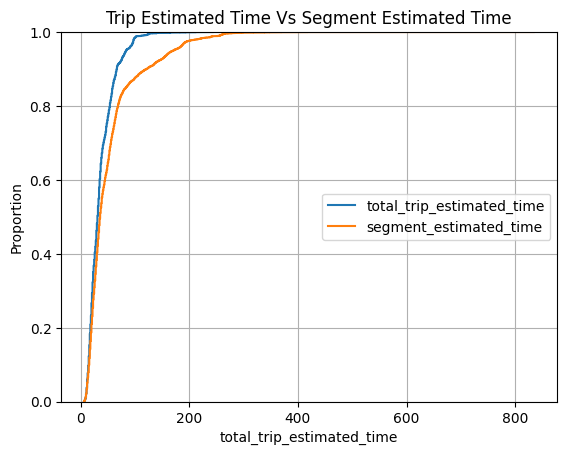

In [716]:
plt.grid()
sns.ecdfplot(Group_A,label = 'total_trip_estimated_time')
sns.ecdfplot(Group_B,label ='segment_estimated_time')
plt.legend(loc='center right')
plt.title("Trip Estimated Time Vs Segment Estimated Time")
plt.show()

Findings:
> 1. P_value is lessa than alpha, means the probability of seeing such a large difference between total_trip_estimated_time and segment_estimated_time by **random chance**—if they were actually from the same distribution—is **effectively zero**.

> 2. The segment estimated times have much higher variance (unpredictability) compared to the tightly clustered trip estimated times.

> 3. The trip actual time distribution is consistently to the left of the segment actual time distribution. This can be due to certain "stationary" or "buffer" periods that are included in individual segment records.

> **Quantifying estimation errors in time calculation**

In [717]:
from datetime import time
time_df = cart_trip_level[['total_trip_estimated_time','total_trip_actual_time']].copy()
time_df.loc[:, 'time_error']  = cart_trip_level['total_trip_estimated_time'] - cart_trip_level['total_trip_actual_time']

time_df['total_trip_estimated_time'] = 	round(time_df['total_trip_estimated_time']).astype('int')
time_df['total_trip_actual_time'] = 	round(time_df['total_trip_actual_time']).astype('int')
time_df['time_error'] = 	round(time_df['time_error']).astype('int')

In [718]:
time_df.head()

,total_trip_estimated_time,total_trip_actual_time,time_error
0,42,96,-54
1,15,59,-44
2,12,40,-28
3,13,24,-11
4,18,39,-21


Creating bins and checking which time bin is prone to more errors

creating time bins

In [724]:
time_df['time_bin'] = pd.qcut(time_df['total_trip_estimated_time'], q=5,
                              labels = ['<-18 mts','-18 to -26 mts','-26 to -35 mts','-35 to -54 mts','>-54 mts'])
time_df.head()

,total_trip_estimated_time,total_trip_actual_time,time_error,time_bin
0,42,96,-54,-35 to -54 mts
1,15,59,-44,<-18 mts
2,12,40,-28,<-18 mts
3,13,24,-11,<-18 mts
4,18,39,-21,<-18 mts


In [725]:
error_analysis = round(time_df.groupby('time_bin', observed = False).agg({
    'time_error': 'median'
}))

print(error_analysis)

                time_error
time_bin                  
<-18 mts             -24.0
-18 to -26 mts       -33.0
-26 to -35 mts       -38.0
-35 to -54 mts       -42.0
>-54 mts             -78.0


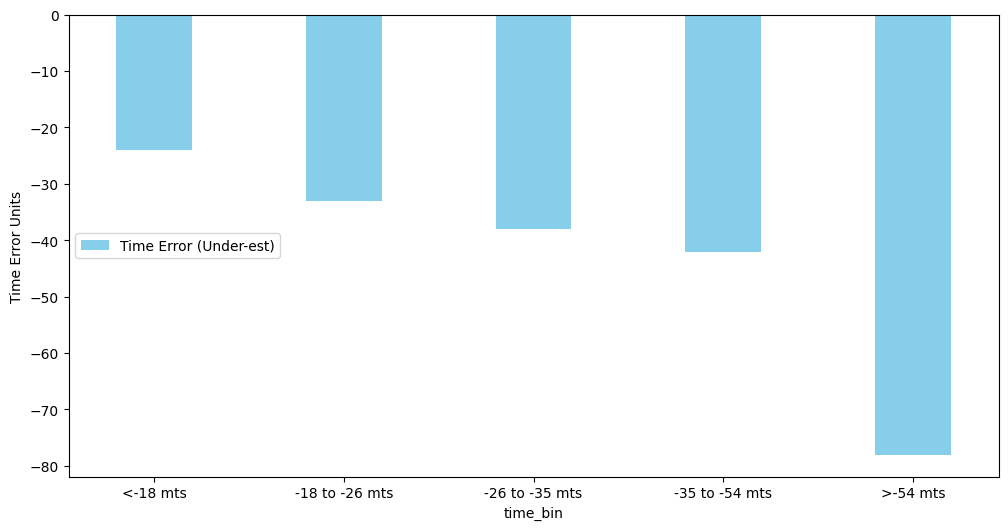

In [726]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Distance Bias (Over-estimation)
error_analysis['time_error'].plot(kind='bar', ax=ax1, color='skyblue', width=0.4, label='Time Error (Under-est)')
ax1.set_ylabel('Time Error Units')
plt.xticks(rotation=0,ha='center')
# plt.ylim(time_df['time_error'].min() - 5, time_df['time_error'].max() + 5)
ax1.legend(loc='center left')
plt.show()

OSRM errors are more when estimating time for longer trips

> **Quantifying estimation errors in distance calculation**

In [730]:
dist_df = cart_trip_level[['total_trip_estimated_distance','total_trip_actual_distance']].copy()
dist_df.loc[:, 'distance_error']  = cart_trip_level['total_trip_estimated_distance'] - cart_trip_level['total_trip_actual_distance']

dist_df['total_trip_estimated_distance'] = 	round(dist_df['total_trip_estimated_distance']).astype('int')
dist_df['total_trip_actual_distance'] = 	round(dist_df['total_trip_actual_distance']).astype('int')
dist_df['distance_error'] = 	round(dist_df['distance_error']).astype('int')

In [731]:
dist_df.head()

,total_trip_estimated_distance,total_trip_actual_distance,distance_error
0,57,49,8
1,20,17,3
2,16,15,1
3,12,9,3
4,15,12,3


Creating bins and checking which distance bin is prone to more errors

In [735]:
dist_df['dist_bin'] = pd.qcut(dist_df['total_trip_estimated_distance'], q=5,
                              labels = ['<19 kms','19-28 kms','28-38 kms','38-54 kms','> 54 kms'])
dist_df.head()

,total_trip_estimated_distance,total_trip_actual_distance,distance_error,dist_bin
0,57,49,8,> 54 kms
1,20,17,3,19-28 kms
2,16,15,1,<19 kms
3,12,9,3,<19 kms
4,15,12,3,<19 kms


In [736]:
error_analysis = round(dist_df.groupby('dist_bin', observed = False).agg({
    'distance_error': 'mean',
}))

print(error_analysis)

           distance_error
dist_bin                 
<19 kms               3.0
19-28 kms             6.0
28-38 kms             8.0
38-54 kms            10.0
> 54 kms             24.0


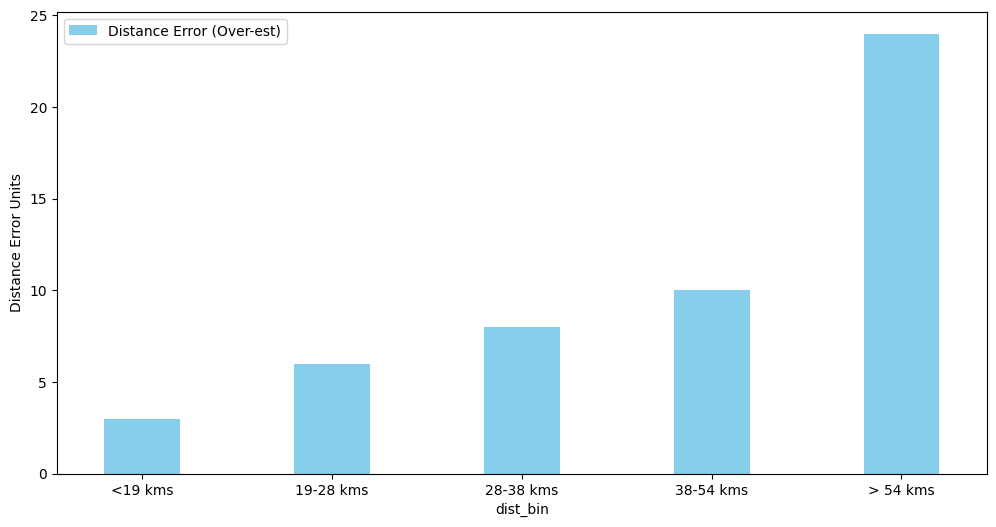

In [737]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Distance Bias (Over-estimation)
error_analysis['distance_error'].plot(kind='bar', ax=ax1, color='skyblue', width=0.4, label='Distance Error (Over-est)')
ax1.set_ylabel('Distance Error Units')
plt.xticks(rotation=0,ha='center')
ax1.legend(loc='upper left')
plt.show()

The system is more prone to error for higher trip distances.

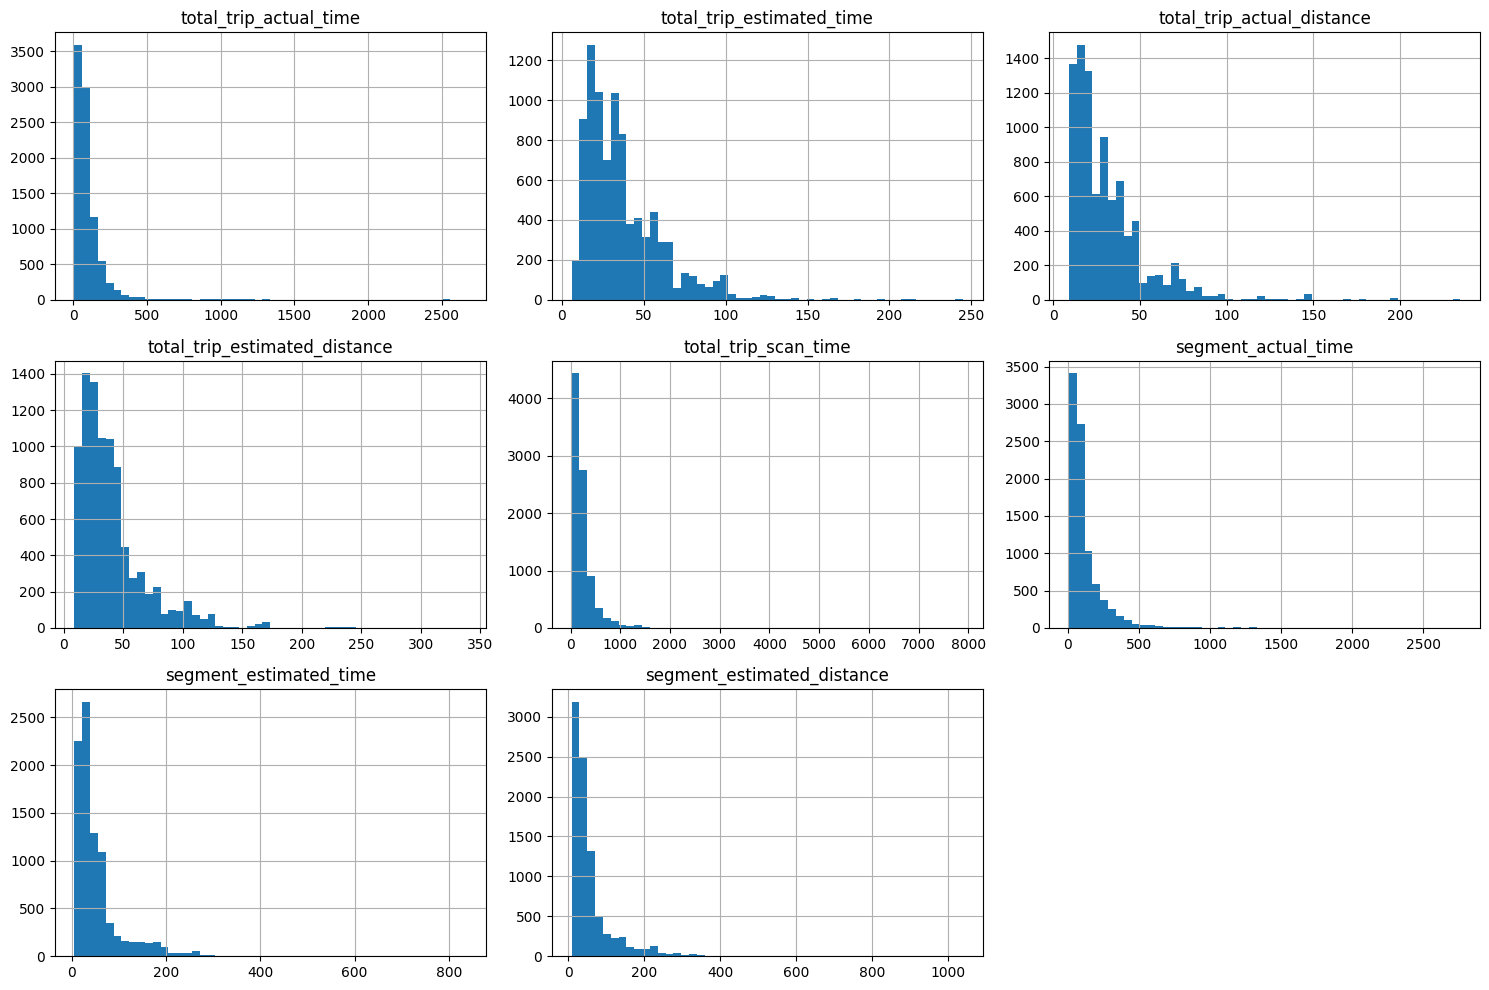

In [738]:
cart_trip_level.hist(bins=50, figsize=(15, 10))
plt.tight_layout()
plt.show()

All features are right-skewed which indicates most of the trips are either  of short distance or short time period journey.

####**Cart_segment_level_data**

In [740]:
df_cart.head(2)

,data,trip_creation_time,shipment_mode,trip_uuid,source_center,source_name,destination_center,destination_name,total_trip_scan_time,od_start_time,...,estimated_time,estimated_distance,segment_actual_time,segment_estimated_time,segment_estimated_distance,source_state,destination_state,date,year,month
0,training,2018-09-20 02:35:36.476840,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),195,2018-09-20 03:21:32.418600,...,11,11.9653,14,11,11.9653,Gujarat,Gujarat,2018-09-20,2018,9
1,training,2018-09-20 02:35:36.476840,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),195,2018-09-20 03:21:32.418600,...,20,21.7243,10,9,9.759,Gujarat,Gujarat,2018-09-20,2018,9


In [741]:
df_cart.drop(['trip_creation_time','source_name', 'destination_name'],axis=1, inplace=True)
df_cart.head(2)

,data,shipment_mode,trip_uuid,source_center,destination_center,total_trip_scan_time,od_start_time,total_trip_actual_distance,start_scan_to_end_scan,total_trip_actual_time,...,estimated_time,estimated_distance,segment_actual_time,segment_estimated_time,segment_estimated_distance,source_state,destination_state,date,year,month
0,training,Carting,trip-153741093647649320,IND388121AAA,IND388620AAB,195,2018-09-20 03:21:32.418600,43.595802,86,102,...,11,11.9653,14,11,11.9653,Gujarat,Gujarat,2018-09-20,2018,9
1,training,Carting,trip-153741093647649320,IND388121AAA,IND388620AAB,195,2018-09-20 03:21:32.418600,43.595802,86,102,...,20,21.7243,10,9,9.759,Gujarat,Gujarat,2018-09-20,2018,9


In [742]:
col_to_move = df_cart.pop('date')
df_cart.insert(1,'date',col_to_move)

col_to_move = df_cart.pop('year')
df_cart.insert(2,'year',col_to_move)

col_to_move = df_cart.pop('month')
df_cart.insert(3,'month',col_to_move)

In [743]:
cart_segment_level = df_cart.copy()

cart_segment_level.head(2)

,data,date,year,month,shipment_mode,trip_uuid,source_center,destination_center,total_trip_scan_time,od_start_time,...,total_trip_estimated_time,actual_time,total_trip_estimated_distance,estimated_time,estimated_distance,segment_actual_time,segment_estimated_time,segment_estimated_distance,source_state,destination_state
0,training,2018-09-20,2018,9,Carting,trip-153741093647649320,IND388121AAA,IND388620AAB,195,2018-09-20 03:21:32.418600,...,45,14,54.2181,11,11.9653,14,11,11.9653,Gujarat,Gujarat
1,training,2018-09-20,2018,9,Carting,trip-153741093647649320,IND388121AAA,IND388620AAB,195,2018-09-20 03:21:32.418600,...,45,24,54.2181,20,21.7243,10,9,9.759,Gujarat,Gujarat


####**Checking outliers**

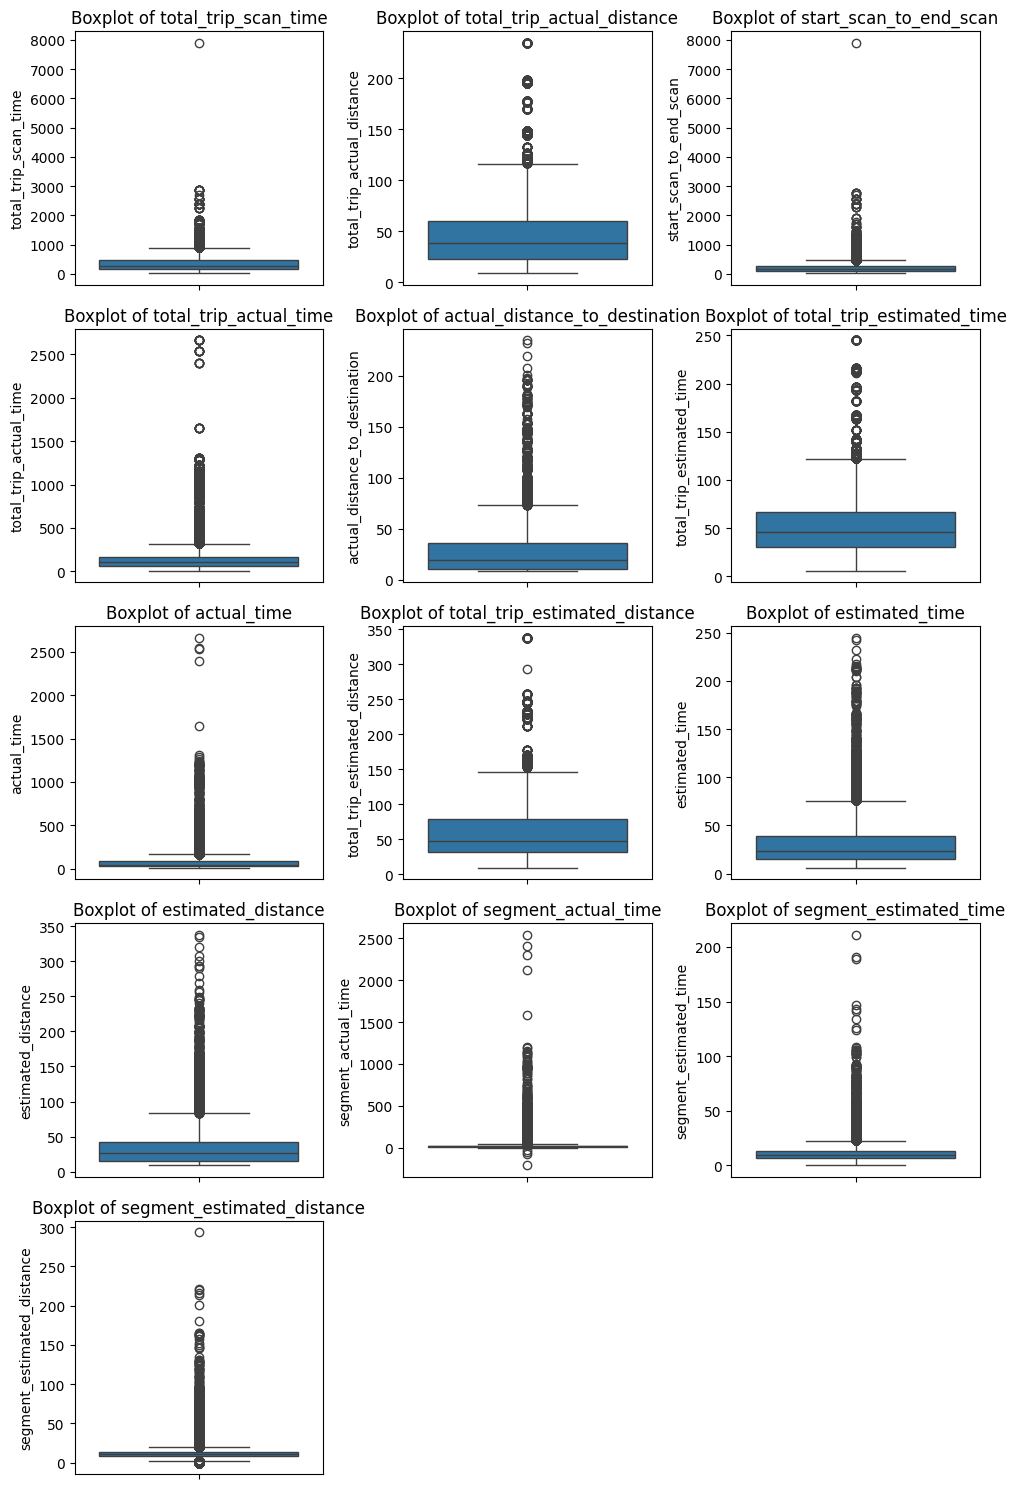

In [744]:
numeric_cols = cart_segment_level.select_dtypes(include=['number'])
num_cols = numeric_cols.iloc[:,2:].columns

plt.figure(figsize=(10, 15))

# 3. Loop through columns and create subplots
for i, col in enumerate(num_cols):
    plt.subplot(len(num_cols) // 3 + 1, 3, i + 1) # Create a grid (3 columns wide)
    sns.boxplot(y=numeric_cols[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout() # Ensures titles and labels don't overlap
plt.show()

removing it

In [745]:
# Calculate Q1, Q3, and IQR for all columns at once
Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)
IQR = Q3 - Q1

#  Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mask = ((numeric_cols >= lower_bound) & (numeric_cols <= upper_bound)).all(axis=1)

# Apply the mask to your original dataframe
df_cart_cleaned = df_cart[mask]

In [746]:
df_cart_cleaned.shape

(26764, 24)

####**Normalizing numerical data**

In [748]:
numerical_cols = df_cart_cleaned.select_dtypes(include=['number'])
for cols in numerical_cols:
  print(cols)
  print(df_cart[cols].max())
  print(df_cart[cols].min())
  print("="*20)

year
2018
2018
month
10
9
total_trip_scan_time
7898
23
total_trip_actual_distance
234.8649063546292
9.00246144174878
start_scan_to_end_scan
7898
20
total_trip_actual_time
2664
9
actual_distance_to_destination
234.8649063546292
9.00004535977208
total_trip_estimated_time
245
6
actual_time
2664
9
total_trip_estimated_distance
337.81870000000004
9.0729
estimated_time
245
6
estimated_distance
337.81870000000004
9.0082
segment_actual_time
2541
-211
segment_estimated_time
211
0
segment_estimated_distance
293.3271
0.0


The range of many columns are high, which means we have to carry out normalization to ensure that features with larger numerical ranges don't dominate the analysis just because of their size

In [749]:
num_cols

Index(['total_trip_scan_time', 'total_trip_actual_distance',
       'start_scan_to_end_scan', 'total_trip_actual_time',
       'actual_distance_to_destination', 'total_trip_estimated_time',
       'actual_time', 'total_trip_estimated_distance', 'estimated_time',
       'estimated_distance', 'segment_actual_time', 'segment_estimated_time',
       'segment_estimated_distance'],
      dtype='object')

In [750]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_cart_cleaned[num_cols]= scaler.fit_transform(df_cart_cleaned[num_cols])
df_cart_cleaned

/tmp/ipython-input-2239284702.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cart_cleaned[num_cols]= scaler.fit_transform(df_cart_cleaned[num_cols])


,data,date,year,month,shipment_mode,trip_uuid,source_center,destination_center,total_trip_scan_time,od_start_time,...,total_trip_estimated_time,actual_time,total_trip_estimated_distance,estimated_time,estimated_distance,segment_actual_time,segment_estimated_time,segment_estimated_distance,source_state,destination_state
0,training,2018-09-20,2018,9,Carting,trip-153741093647649320,IND388121AAA,IND388620AAB,0.197022,2018-09-20 03:21:32.418600,...,0.395833,0.032258,0.332380,0.072464,0.039585,0.396226,0.476190,0.563184,Gujarat,Gujarat
1,training,2018-09-20,2018,9,Carting,trip-153741093647649320,IND388121AAA,IND388620AAB,0.197022,2018-09-20 03:21:32.418600,...,0.395833,0.096774,0.332380,0.202899,0.170222,0.320755,0.380952,0.435403,Gujarat,Gujarat
2,training,2018-09-20,2018,9,Carting,trip-153741093647649320,IND388121AAA,IND388620AAB,0.197022,2018-09-20 03:21:32.418600,...,0.395833,0.200000,0.332380,0.318841,0.314998,0.433962,0.285714,0.496574,Gujarat,Gujarat
3,training,2018-09-20,2018,9,Carting,trip-153741093647649320,IND388121AAA,IND388620AAB,0.197022,2018-09-20 03:21:32.418600,...,0.395833,0.341935,0.332380,0.492754,0.489322,0.528302,0.523810,0.624407,Gujarat,Gujarat
4,training,2018-09-20,2018,9,Carting,trip-153741093647649320,IND388121AAA,IND388620AAB,0.197022,2018-09-20 03:21:32.418600,...,0.395833,0.380645,0.332380,0.550725,0.605195,0.245283,0.190476,0.096958,Gujarat,Gujarat
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45165,training,2018-09-13,2018,9,Carting,trip-153687166594261221,IND638501AAB,IND641062AAD,0.229095,2018-09-14 04:43:39.516488,...,0.718750,0.606452,0.529827,0.927536,0.887458,0.622642,0.428571,0.406051,Tamil Nadu,Tamil Nadu
45171,training,2018-09-17,2018,9,Carting,trip-153718412883843340,IND600056AAB,IND600032AAB,0.106529,2018-09-17 11:35:28.838714,...,0.270833,0.148387,0.203898,0.057971,0.012665,0.735849,0.428571,0.446714,Tamil Nadu,Tamil Nadu
45172,training,2018-09-17,2018,9,Carting,trip-153718412883843340,IND600056AAB,IND600032AAB,0.106529,2018-09-17 11:35:28.838714,...,0.270833,0.316129,0.203898,0.188406,0.158540,0.622642,0.333333,0.501329,Tamil Nadu,Tamil Nadu
45173,training,2018-09-17,2018,9,Carting,trip-153718412883843340,IND600056AAB,IND600032AAB,0.106529,2018-09-17 11:35:28.838714,...,0.270833,0.419355,0.203898,0.304348,0.288181,0.415094,0.333333,0.431088,Tamil Nadu,Tamil Nadu


In [751]:
cat_cols = df_cart_cleaned.select_dtypes(include=['string']).iloc[:,1:5] # removing data column
cat_cols

,shipment_mode,trip_uuid,source_center,destination_center
0,Carting,trip-153741093647649320,IND388121AAA,IND388620AAB
1,Carting,trip-153741093647649320,IND388121AAA,IND388620AAB
2,Carting,trip-153741093647649320,IND388121AAA,IND388620AAB
3,Carting,trip-153741093647649320,IND388121AAA,IND388620AAB
4,Carting,trip-153741093647649320,IND388121AAA,IND388620AAB
...,...,...,...,...
45165,Carting,trip-153687166594261221,IND638501AAB,IND641062AAD
45171,Carting,trip-153718412883843340,IND600056AAB,IND600032AAB
45172,Carting,trip-153718412883843340,IND600056AAB,IND600032AAB
45173,Carting,trip-153718412883843340,IND600056AAB,IND600032AAB


In [752]:
cat_cols.nunique()

,0
shipment_mode,1
trip_uuid,6900
source_center,562
destination_center,556


Encoding cat_cols to numbers

In [753]:
df_cart_cleaned.drop(['source_center', 'destination_center'],axis=1, inplace=True)

/tmp/ipython-input-1906822856.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cart_cleaned.drop(['source_center', 'destination_center'],axis=1, inplace=True)


In [754]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_cart_cleaned.loc[:,"shipment_mode"] = le.fit_transform(df_cart_cleaned["shipment_mode"])
df_cart_cleaned.loc[:,"trip_uuid"] = le.fit_transform(df_cart_cleaned["trip_uuid"])
df_cart_cleaned.loc[:,"source_state"] = le.fit_transform(df_cart_cleaned["source_state"])
df_cart_cleaned.loc[:,"destination_state"] = le.fit_transform(df_cart_cleaned["destination_state"])

/tmp/ipython-input-348653719.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 0 0 0]' has dtype incompatible with string, please explicitly cast to a compatible dtype first.
  df_cart_cleaned.loc[:,"shipment_mode"] = le.fit_transform(df_cart_cleaned["shipment_mode"])
/tmp/ipython-input-348653719.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[3119 3119 3119 ... 2063 2063 2063]' has dtype incompatible with string, please explicitly cast to a compatible dtype first.
  df_cart_cleaned.loc[:,"trip_uuid"] = le.fit_transform(df_cart_cleaned["trip_uuid"])


In [755]:
col_to_move = df_cart_cleaned.pop('source_state')
df_cart_cleaned.insert(6,'source_state', col_to_move)

col_to_move = df_cart_cleaned.pop('destination_state')
df_cart_cleaned.insert(7,'destination_state', col_to_move)

In [757]:
df_cart_cleaned.head(2)

,data,date,year,month,shipment_mode,trip_uuid,source_state,destination_state,total_trip_scan_time,od_start_time,...,total_trip_actual_time,actual_distance_to_destination,total_trip_estimated_time,actual_time,total_trip_estimated_distance,estimated_time,estimated_distance,segment_actual_time,segment_estimated_time,segment_estimated_distance
0,training,2018-09-20,2018,9,0,3119,9,9,0.197022,2018-09-20 03:21:32.418600,...,0.299035,0.022214,0.395833,0.032258,0.33238,0.072464,0.039585,0.396226,0.476190,0.563184
1,training,2018-09-20,2018,9,0,3119,9,9,0.197022,2018-09-20 03:21:32.418600,...,0.299035,0.153759,0.395833,0.096774,0.33238,0.202899,0.170222,0.320755,0.380952,0.435403


In [758]:
df_FTL_cleaned.head(2)

,data,date,year,month,shipment_mode,trip_uuid,source_state,destination_state,total_trip_scan_time,od_start_time,...,total_trip_actual_time,actual_distance_to_destination,total_trip_estimated_time,actual_time,total_trip_estimated_distance,estimated_time,estimated_distance,segment_actual_time,segment_estimated_time,segment_estimated_distance
0,training,2018-09-23,2018,9,0,3249,16,16,0.056478,2018-09-23 06:42:06.021680,...,0.036126,0.007164,0.049014,0.013306,0.048608,0.012733,0.007998,0.520548,0.533333,0.505093
1,training,2018-09-23,2018,9,0,3249,16,16,0.056478,2018-09-23 06:42:06.021680,...,0.036126,0.025445,0.049014,0.032753,0.048608,0.029383,0.027894,0.506849,0.633333,0.617862


##Final Analysis on both dataset

Checking from where most orders are coming from

Overall

In [787]:
df.groupby('destination_state')['trip_uuid'].nunique().sort_values(ascending=False).reset_index().loc[:9]

,destination_state,trip_uuid
0,Maharashtra,2637
1,Karnataka,2425
2,Haryana,1800
3,Tamil Nadu,1097
4,Uttar Pradesh,882
5,Telangana,856
6,Gujarat,791
7,West Bengal,713
8,Punjab,693
9,Delhi,674


Carting

In [788]:
df_cart.groupby('destination_state')['trip_uuid'].nunique().sort_values(ascending=False).reset_index().loc[:9]

,destination_state,trip_uuid
0,Maharashtra,1979
1,Karnataka,1789
2,Haryana,1084
3,Tamil Nadu,753
4,Delhi,549
5,West Bengal,434
6,Uttar Pradesh,411
7,Gujarat,396
8,Telangana,388
9,Kerala,210


FTL

In [790]:
df_FTL.groupby('destination_state')['trip_uuid'].nunique().sort_values(ascending=False).reset_index().loc[:9]

,destination_state,trip_uuid
0,Haryana,716
1,Maharashtra,658
2,Karnataka,636
3,Punjab,524
4,Uttar Pradesh,471
5,Telangana,468
6,Andhra Pradesh,408
7,Gujarat,395
8,Rajasthan,365
9,Bihar,365


Maximum orders are coming from major states which are industrial and technology hubs

##**Recommendations**

> **1. Route_type - Carting & FTL has entirely different characteristics in distance/time estimation and reality. So seperate strategy should be made to cater for delays and increasing operational efficiency.**

> **2. OSRM estimation needs to be optimised for calculating distance and time, failure of which can have cascading effect on cost estimation and efficiency.**

>**3. Most of the deviations in distance/time calculation are observed in higher duration journeys which can be attributed to many external factors like GPS help, local knowledge of drivers.**

> **4. Most orders are coming from major industrial and technological hubs. So fleet availability and manpower management should optimised to avoid operational delays.**